In [588]:
# Importing essential libraries for data analysis and visualization:
# pandas for data manipulation, numpy for numerical operations,
# matplotlib and seaborn for creating various plots and visualizations.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [589]:
# Loading the cleaned Netflix dataset from a CSV file into a pandas DataFrame for analysis.
df = pd.read_csv("Netflix_cleaned_dataset.csv")

In [590]:
# Displaying the first few rows of the cleaned Netflix dataset to get an overview of the data.
df.head()

,show_id,type,title,director,cast,country,date_added,month_added,week_added,year_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,United States,2021-09-25,9,38,2021,2020,PG-13,80-100,Documentaries
1,s2,TV Show,Blood & Water,Unknown Director,Ama Qamata,South Africa,2021-09-24,9,38,2021,2021,TV-MA,2 Seasons,International TV Shows
2,s2,TV Show,Blood & Water,Unknown Director,Ama Qamata,South Africa,2021-09-24,9,38,2021,2021,TV-MA,2 Seasons,TV Dramas
3,s2,TV Show,Blood & Water,Unknown Director,Ama Qamata,South Africa,2021-09-24,9,38,2021,2021,TV-MA,2 Seasons,TV Mysteries
4,s2,TV Show,Blood & Water,Unknown Director,Khosi Ngema,South Africa,2021-09-24,9,38,2021,2021,TV-MA,2 Seasons,International TV Shows


In [591]:
# Checking the shape of the dataset to understand the number of rows and columns.
df.shape

(201826, 14)

In [592]:
# Check the structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201826 entries, 0 to 201825
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   show_id       201826 non-null  object
 1   type          201826 non-null  object
 2   title         201826 non-null  object
 3   director      201826 non-null  object
 4   cast          201826 non-null  object
 5   country       201826 non-null  object
 6   date_added    201826 non-null  object
 7   month_added   201826 non-null  int64 
 8   week_added    201826 non-null  int64 
 9   year_added    201826 non-null  int64 
 10  release_year  201826 non-null  int64 
 11  rating        201826 non-null  object
 12  duration      201826 non-null  object
 13  listed_in     201826 non-null  object
dtypes: int64(4), object(10)
memory usage: 21.6+ MB


In [593]:
df['date_added'] = pd.to_datetime(df['date_added'])
print(df.dtypes)  # Check the data type after conversion

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
month_added              int64
week_added               int64
year_added               int64
release_year             int64
rating                  object
duration                object
listed_in               object
dtype: object


In [594]:
# Check for missing values
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
month_added     0
week_added      0
year_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [595]:
# Get basic descriptive statistics for numerical columns
df.describe()

,date_added,month_added,week_added,year_added,release_year
count,201826,201826.000000,201826.00000,201826.000000,201826.000000
mean,2019-06-19 06:20:46.816564992,6.636301,26.69546,2018.964712,2013.450155
min,2008-01-01 00:00:00,1.000000,1.00000,2008.000000,1925.000000
25%,2018-06-23 00:00:00,4.000000,14.00000,2018.000000,2012.000000
50%,2019-09-01 00:00:00,7.000000,27.00000,2019.000000,2016.000000
75%,2020-09-10 00:00:00,10.000000,39.00000,2020.000000,2019.000000
max,2021-09-25 00:00:00,12.000000,53.00000,2021.000000,2021.000000
std,NaN,3.441727,15.04950,1.552603,9.005656


In [596]:
# Number of unique show_ids
print(df['show_id'].nunique())

# Total number of rows
print(df.shape[0])

8803
201826


In [597]:
# Count of duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [598]:
#number of distinct titles on the basis of type
df.groupby("type")["title"].nunique()

type
Movie      6104
TV Show    2674
Name: title, dtype: int64

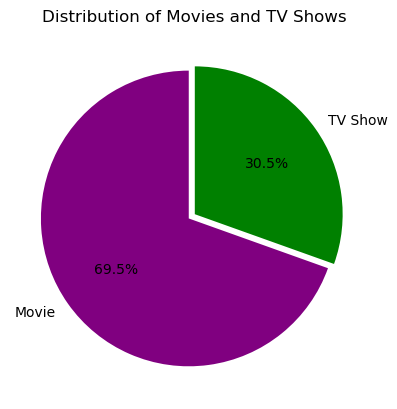

In [599]:
#Distribution of unique Movies and TV Shows (%)
type_counts=df.groupby("type")["title"].nunique()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90,explode=(0.05, 0),colors=['purple','green'])
plt.title('Distribution of Movies and TV Shows')
plt.show()

## 🎬 Type (TV Shows vs Movies)

### 📌 Observation:
- **69.5%** of the titles are Movies, while **30.5%** are TV Shows.
- **Total Distinct Titles:**
  - 🎥 Movies: **6104**
  - 📺 TV Shows: **2674**
  
### 💡 Suggestion:
Focus more on **movie-related trends**, as they represent the majority of the content. To account for the volume difference and enable clearer insights, separate dashboards or visualizations have been created for movies and TV shows.

In [601]:
#Split data into TV Shows and Movies.

df_shows=df[df['type']=='TV Show']
df_movies=df[df['type']=='Movie']

## Function: `Analyze_column_distribution`

This function is used to perform univariate analysis by showing how many **unique values** of a `target_col` (like job titles) exist within each category of a `column_name` (like country).  

### 🔍 Key Features:
- **Data Cleaning:** Excludes irrelevant or missing values from the dataset.
- **Grouping:** Groups the data by the chosen `column_name` and counts the unique values in the `target_col`.
- **Visualization:** Plots a **bar chart** using Seaborn with flexible axis labels and label orientation.
- **Customization Options:**
  - `top_n` categories to focus on.
  - Customizable `x_col` and `y_col` for orientation.
  - Ability to exclude specific values like "Unknown", 0, etc.
- **Enhanced Readability:** Automatically adds value labels to each bar for better readability.

In [603]:
def Analyze_column_distribution(df, column_name, target_col="title", top_n=10, exclude_values=None, x_col="unique_count", y_col=None):
    """
    Plots the top N unique counts of target_col grouped by column_name.
    Excludes unwanted values and places correct value labels depending on orientation.
    Allows flexible choice for x_col and y_col.
    """
    if exclude_values is None:
        exclude_values = ["Unknown", "unknown", "0", 0, "", None]

    # Step 1: Clean the data
    clean_df = df[(~df[column_name].isin(exclude_values)) &(df[column_name].notna())]

    # Step 2: Group and count
    Result = (clean_df.groupby(column_name)[target_col].nunique().sort_values(ascending=False).head(top_n).reset_index()
              .rename(columns={target_col: "unique_count"}))

    print(f"\n🔢 Top {top_n} unique '{target_col}' counts for '{column_name}':")
    print(Result)

    # Step 3: Plot
    plt.figure(figsize=(8, 4))

    # Default behavior for y-axis if not provided
    if y_col is None:
        y_col = column_name
    ax = sns.barplot(data=Result, x=x_col, y=y_col, palette="viridis", hue=column_name, legend=False)

    plt.title(f"Top {top_n} '{column_name}' by Unique {target_col}", fontsize=14, fontweight="bold")
    
    # 🔁 Flexible axis labels based on column names
    x_label = "Number of " + target_col if x_col == "unique_count" else x_col
    y_label = "Group: " + column_name if y_col is None else y_col
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)

    # Step 4: Adaptive label placement based on axis orientation
    for patch in ax.patches:
        if pd.api.types.is_numeric_dtype(ax.get_xticks()):
            width = patch.get_width()
            y = patch.get_y() + patch.get_height() / 2
            ax.text(width + 1, y, str(int(width)), va='center', ha='left', fontweight='bold', color='black')
        elif pd.api.types.is_numeric_dtype(ax.get_yticks()):
            height = patch.get_height()
            x = patch.get_x() + patch.get_width() / 2
            ax.text(x, height + 1, str(int(height)), ha='center', va='bottom', fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

## Function: `Analyze_top_categories`

This function compares the top N categories (such as country, genre, etc.) in **TV shows** and **movies** by counting unique titles in each category. It generates **side-by-side bar charts** for a quick and clear visual comparison.

### 🔍 Key Features:
- **Comparison of Top Categories:** Analyzes the top N categories in TV shows and movies, focusing on unique title counts.
- **Visualization:** Generates side-by-side **bar charts** for easy comparison between the categories.
- **Customizable:** Adjust the number of top categories (`top_n`) and the specific categories to analyze.

In [783]:
def Analyze_top_categories(df_shows, df_movies, category_col, title_col, x_col, y_col, top_n=5, exclude_values=None):


    # Default exclusion list
    if exclude_values is None:
        exclude_values = ["Unknown", "unknown", "0", 0, "", None]
    # Handle missing columns gracefully
    if category_col not in df_shows.columns or category_col not in df_movies.columns:
        print(f"Column '{category_col}' not found in one of the dataframes.")
        return

    # Filter out unwanted or null values
    df_shows = df_shows[(~df_shows[category_col].isin(exclude_values)) & (df_shows[category_col].notna())]
    df_movies = df_movies[(~df_movies[category_col].isin(exclude_values)) & (df_movies[category_col].notna())]

    # Group by category and count unique titles
    top_tv_categories = (df_shows.groupby(category_col)[title_col].nunique().sort_values(ascending=False).head(top_n).reset_index()
                         .rename(columns={title_col: "Count"}))

    top_movie_categories = (df_movies.groupby(category_col)[title_col].nunique().sort_values(ascending=False).head(top_n).reset_index()
                            .rename(columns={title_col: "Count"}))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10,3))

    # TV Shows plot
    sns.barplot(ax=axes[0], data=top_tv_categories, x=x_col, y=y_col, palette="Blues_d", hue=category_col, legend=False)
    axes[0].set_title(f"Top {top_n} Categories for TV Shows", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Number of TV Shows" if x_col == "Count" else x_col)
    axes[0].set_ylabel("Number of TV Shows" if y_col == "Count" else y_col)

    # Movies plot
    sns.barplot(ax=axes[1], data=top_movie_categories, x=x_col, y=y_col, palette="Greens_d", hue=category_col, legend=False)
    axes[1].set_title(f"Top {top_n} Categories for Movies", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Number of Movies" if x_col == "Count" else x_col)
    axes[1].set_ylabel("Number of Movies" if y_col == "Count" else y_col)

    for ax in axes:
        for patch in ax.patches:
            # Case 1: Vertical bar chart (like yours) — y-axis is numeric
            if pd.api.types.is_numeric_dtype(ax.get_yticks()):
                height = patch.get_height()  # bar height = count
                x = patch.get_x() + patch.get_width() / 2  # bar center
                ax.text(x, height +0.5, str(int(height)), ha='center', va='bottom', fontweight='bold', color='black')
    
            # Case 2: Horizontal bar chart (x-axis is numeric)
            elif pd.api.types.is_numeric_dtype(ax.get_xticks()):
                width = patch.get_width()
                y = patch.get_y() + patch.get_height() / 2
                ax.text(width +0.5, y, str(int(width)), ha='left', va='center', fontweight='bold', color='black')
    

    plt.tight_layout()
    plt.show()

## Function: `📈 plot_line_for_column`

This function visualizes trends by plotting the count of unique titles over a numeric column (such as release year or month). It is useful for observing patterns or changes over time.

### 🔍 Key Features:
- **Trend Visualization:** Plots the count of unique titles over a numeric column (e.g., release year, month).
- **Pattern Observation:** Helps in identifying patterns or trends, especially for time-series data.
- **Customizable:** Allows flexibility in choosing the column to visualize and adjusting the visual style.

In [607]:
def plot_line_for_column(df, col, title_col, exclude_values=None):
    """
    Plots a line chart showing unique counts of title_col grouped by a numeric column (e.g., year, month).
    Optionally excludes specific values from the grouping column.
    """

    # Set default excluded values if not provided
    if exclude_values is None:
        exclude_values = ["Unknown", "unknown", "0", 0, "", None]

    # Step 1: Clean the data
    clean_df = df[(~df[col].isin(exclude_values)) & (df[col].notna())]

    # Step 2: Group and count
    data = clean_df.groupby(col)[title_col].nunique().reset_index()

    # Step 3: Plot
    sns.lineplot(data=data, x=col, y=title_col, marker='o', color="purple")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel(f"Unique {title_col}")
    plt.title(f"Trend of Unique {title_col} by {col.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()


In [608]:
#Displays the column names of the DataFrame `df`.
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'month_added', 'week_added', 'year_added', 'release_year', 'rating',
       'duration', 'listed_in'],
      dtype='object')


🔢 Top 10 unique 'title' counts for 'director':
              director  unique_count
0        Rajiv Chilaka            22
1            Jan Suter            21
2          Raúl Campos            19
3         Marcus Raboy            16
4          Suhas Kadav            16
5            Jay Karas            15
6  Cathy Garcia-Molina            13
7      Martin Scorsese            12
8          Jay Chapman            12
9      Youssef Chahine            12


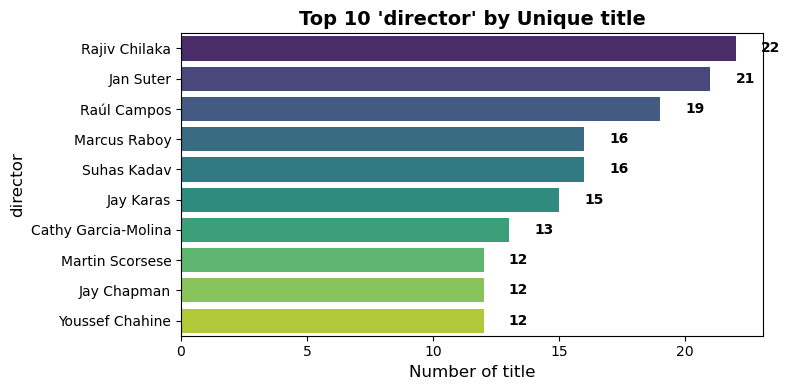

In [609]:
#Shows top 15 directors with the most unique titles.
Analyze_column_distribution(df,column_name='director',target_col="title",top_n=10,exclude_values=['Unknown Director'],x_col="unique_count",y_col=None)

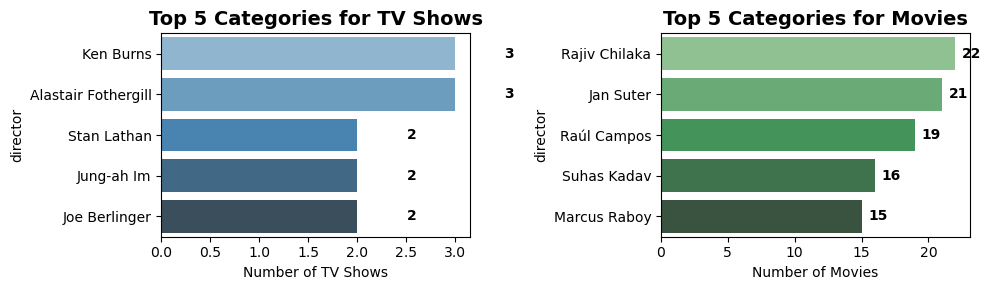

In [785]:
#Compares top `n` categories (e.g., directors) across shows and movies based on unique title counts.  Helps identify leading contributors in each category.
Analyze_top_categories(df_shows,df_movies,category_col='director',title_col='title',exclude_values=['Unknown Director'], x_col='Count',y_col='director',top_n=5)

## 🎬 Director Highlights:
- **Top Directors:**
  - Rajiv Chilaka (22 titles)
  - Jan Suter (21 titles)
  - Raúl Campos (19 titles)
- **TV Show Directors:** Ken Burns & Alastair Fothergill (3 titles each)
- **Movie Directors:** Chilaka, Suter, Campos (16–22 titles)

### ➤ Key Insight:
Directors like **Rajiv Chilaka**, **Jan Suter**, and **Raúl Campos** dominate in **movie content**, suggesting a strong influence on the platform’s film offerings. On the other hand, **TV shows** feature directors like **Ken Burns** and **Alastair Fothergill**, who lead with fewer titles.


🔢 Top 10 unique 'title' counts for 'cast':
               cast  unique_count
0       Anupam Kher            43
1    Shah Rukh Khan            35
2     Julie Tejwani            33
3  Naseeruddin Shah            32
4  Takahiro Sakurai            32
5      Rupa Bhimani            31
6      Akshay Kumar            30
7           Om Puri            30
8         Yuki Kaji            29
9      Paresh Rawal            28


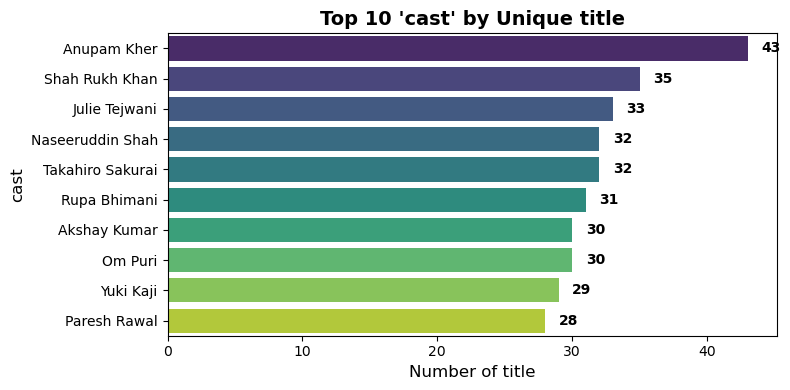

In [612]:
#Displays the top 10 actors based on the number of unique titles they appear in, excluding unknown entries.
Analyze_column_distribution(df,column_name='cast',target_col="title",top_n=10,exclude_values=['Unknown Actor'],x_col="unique_count",y_col=None)

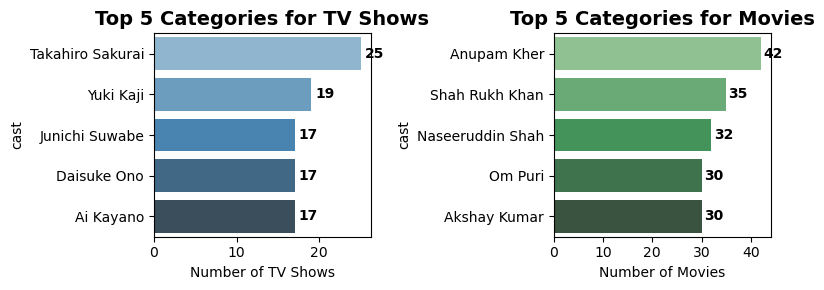

In [777]:
#Compares the top 5 actors by unique title count in both shows and movies, excluding unknown entries.
Analyze_top_categories(df_shows,df_movies,category_col='cast',title_col='title', x_col='Count',y_col='cast',top_n=5,exclude_values=['Unknown Actor'])

## 🟪 Cast Highlights:
- **Top Actors:**
  - Anupam Kher (43 titles)
  - Shah Rukh Khan (35 titles)
  - Julie Tejwani (33 titles)
  - Naseeruddin Shah (32 titles)
- **TV Show Cast:** Takahiro Sakurai (25 titles), Yūki Kaji (19 titles)
- **Movie Cast:** Kher (42 titles), Khan (35 titles), Shah (32 titles)

### ➤ Key Insight:
Actors like Kher, Khan, and Shah play a central role in the platform’s content, while Japanese voice actors dominate TV shows and Bollywood actors lead movies, reflecting regional trends.


🔢 Top 10 unique 'title' counts for 'country':
          country  unique_count
0   United States          3851
1           India          1140
2  United Kingdom           842
3          Canada           484
4          France           413
5           Japan           365
6     South Korea           260
7           Spain           249
8         Germany           234
9          Mexico           184


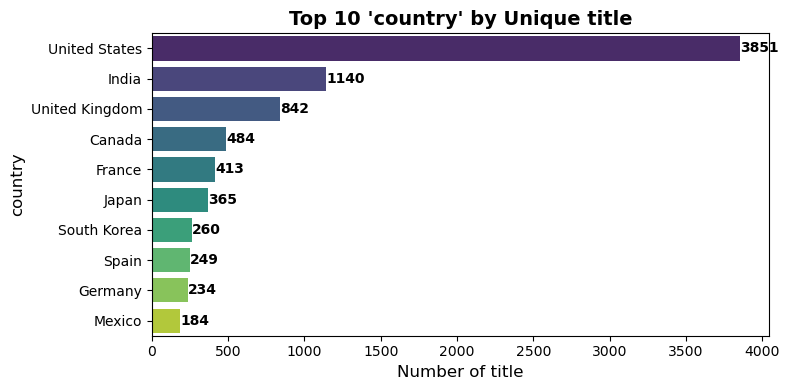

In [615]:
#Shows the top 10 countries with the most unique titles, excluding unknown entries.
Analyze_column_distribution(df,column_name='country',target_col="title",top_n=10,exclude_values=['Unknown Country'],x_col="unique_count",y_col=None)

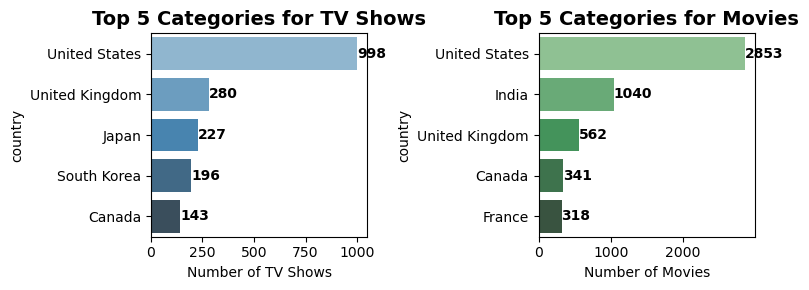

In [779]:
#Compares the top 5 countries producing the most unique titles in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='country',exclude_values=['Unknown Country'],title_col='title', x_col='Count',y_col='country',top_n=5)

## 🌍 Country Highlights:
- **Top Countries:**
  - United States (3851 titles)
  - India (1140 titles)
  - United Kingdom (842 titles)
- **TV Show Country Breakdown:** 
  - United States (998 titles)
  - United Kingdom (280 titles)
  - Japan (227 titles)
- **Movie Country Breakdown:**
  - United States (2853 titles)
  - India (1040 titles)
  - United Kingdom (562 titles)

### ➤ Key Insight:
The United States dominates in both TV shows and movies, with India and the United Kingdom making strong contributions in their respective categories.


🔢 Top 10 unique 'title' counts for 'date_added':
  date_added  unique_count
0 2020-01-01           110
1 2019-11-01            91
2 2018-03-01            75
3 2019-12-31            74
4 2018-10-01            71
5 2019-10-01            62
6 2021-07-01            61
7 2018-11-01            60
8 2021-09-01            58
9 2018-01-01            55


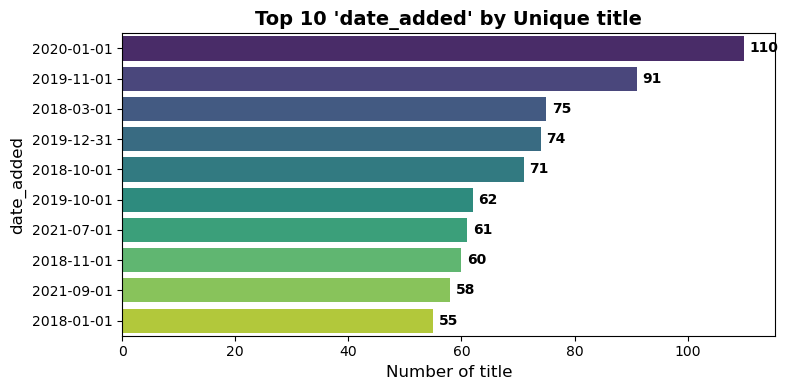

In [618]:
#Shows the top 10 dates when the most unique titles were added to Netflix.
Analyze_column_distribution(df,column_name='date_added',target_col="title",top_n=10,exclude_values=['Unknown Director'],x_col="unique_count",y_col=None)

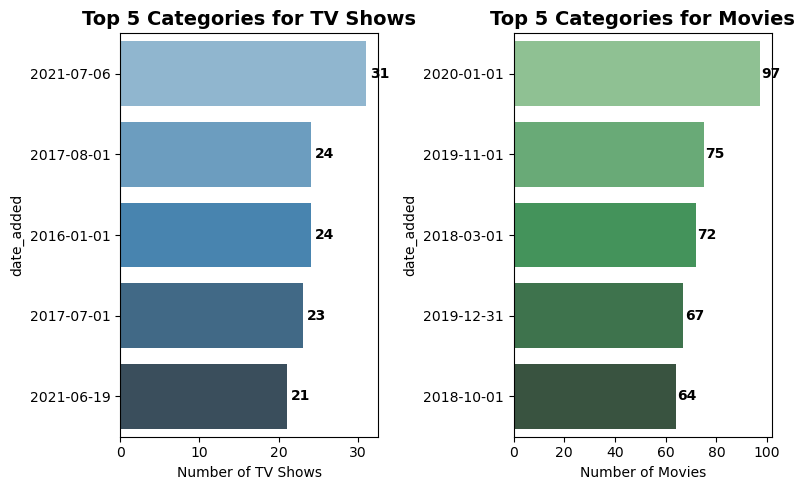

In [619]:
#Compares the top 5 dates with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='date_added',title_col='title', x_col='Count',y_col='date_added',top_n=5)

## 🗓️ Date Added Highlights:

### ➤ Key Insight:
Movies are added in bulk at the start or end of the year, especially around 01/01/2020, indicating strategic additions. TV shows are added in smaller, scattered batches, often mid-year, suggesting a content refresh plan for movies around holidays.


🔢 Top 10 unique 'title' counts for 'month_added':
   month_added  unique_count
0            7           832
1           12           813
2            9           769
3            4           764
4           10           756
5            8           747
6            3           740
7            1           737
8            6           725
9           11           706


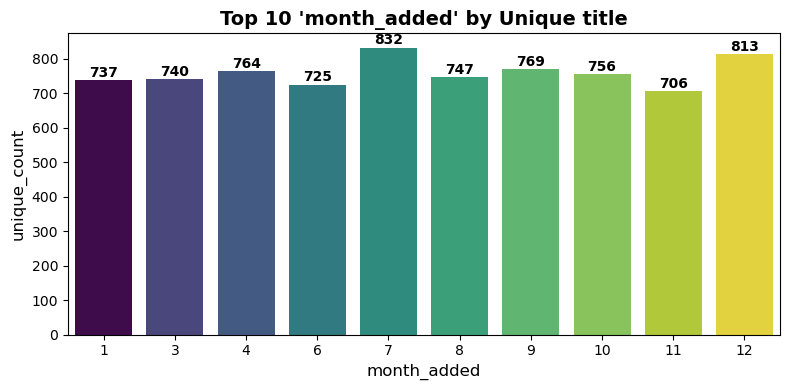

In [621]:
# Displays how many unique titles were added in each month, showing the top 10 months.
Analyze_column_distribution(df,column_name='month_added',target_col="title",top_n=10,exclude_values=[None],x_col='month_added',y_col="unique_count")

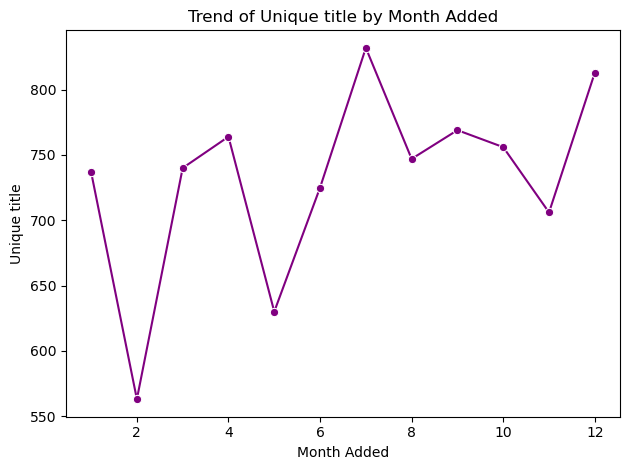

In [622]:
###### Visualizes the trend of unique titles added over each month.
plot_line_for_column(df, "month_added", "title")

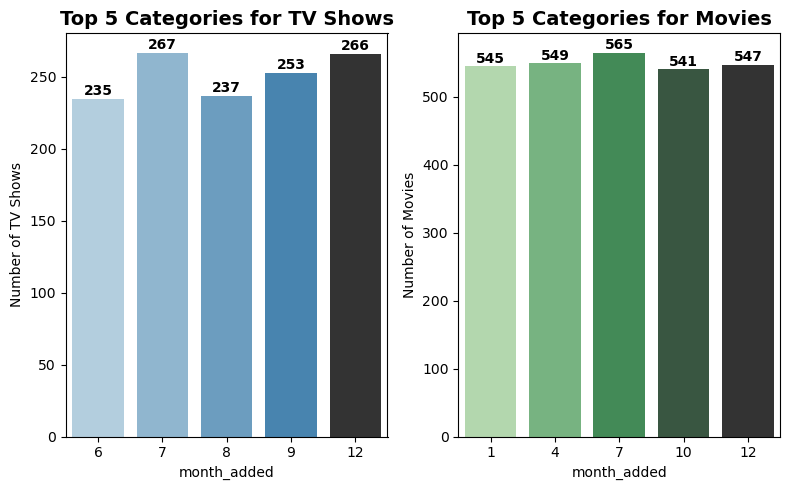

In [623]:
#### Compares the top 5 months with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='month_added',title_col='title', x_col='month_added',y_col='Count',top_n=5)

## 🗓️ Month Added Highlights:

### ➤ Key Insight:
July and December are peak months for both TV shows and movies, likely due to mid-year breaks and holidays. April, September, and October also show strong activity, indicating a strategic content rollout aligned with global viewer cycles.


🔢 Top 10 unique 'title' counts for 'week_added':
   week_added  unique_count
0           1           372
1          44           318
2          40           287
3          31           269
4          26           269
5          35           265
6           9           254
7          13           249
8          27           241
9          18           234


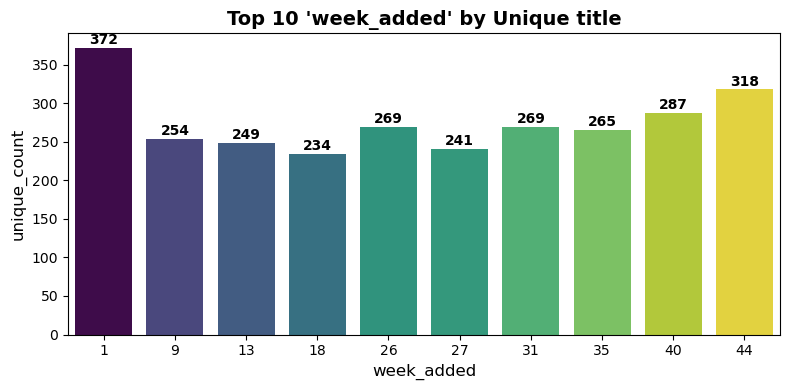

In [625]:
### Displays the top 10 weeks with the most unique title additions.
Analyze_column_distribution(df,column_name='week_added',target_col="title",top_n=10,exclude_values=[None],y_col="unique_count",x_col='week_added')

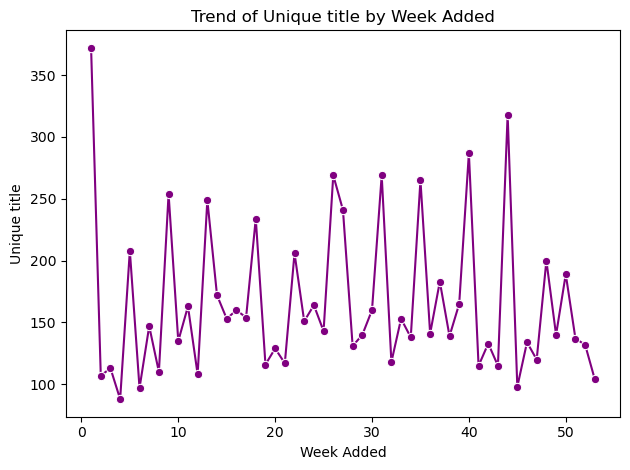

In [626]:
#Visualizes the trend of unique titles added over each week.
plot_line_for_column(df, "week_added", "title")

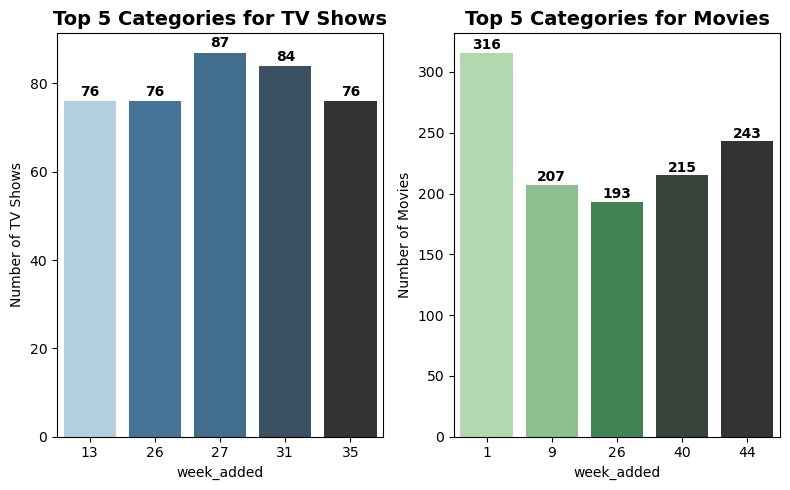

In [627]:
#Compares the top 5 weeks with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='week_added',title_col='title', x_col='week_added',y_col='Count',top_n=5)

## 📅 Week Added Highlights:

### ➤ Key Insight:
Week 1 (early January) stands out for **movies**, hinting at a strong start-of-year content push. **TV shows** are more spread out, with additions peaking in mid-year weeks like Week 27 and 31. This reflects a dual strategy: capitalizing on holiday viewership for **movies** and maintaining regular engagement with episodic **content** mid-year.


🔢 Top 10 unique 'title' counts for 'year_added':
   year_added  unique_count
0        2019          2005
1        2020          1877
2        2018          1649
3        2021          1494
4        2017          1185
5        2016           432
6        2015            82
7        2014            24
8        2011            13
9        2013            11


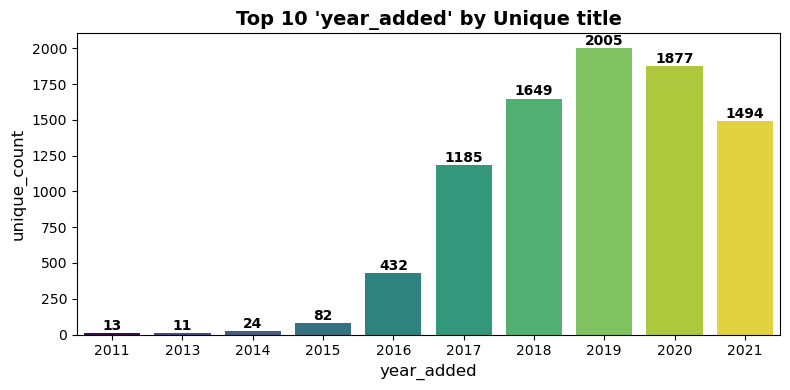

In [629]:
##### Displays the top 10 years with the most unique title additions.
Analyze_column_distribution(df,column_name='year_added',target_col="title",top_n=10,exclude_values=[None],x_col='year_added',y_col="unique_count")

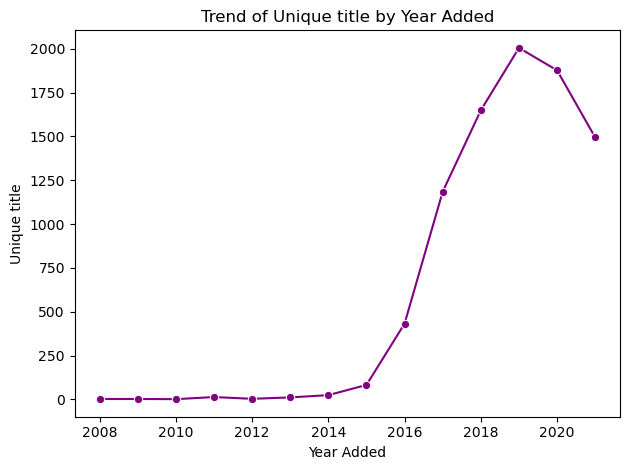

In [630]:
# Visualizes the trend of unique titles added over each year.
plot_line_for_column(df, "year_added", "title")

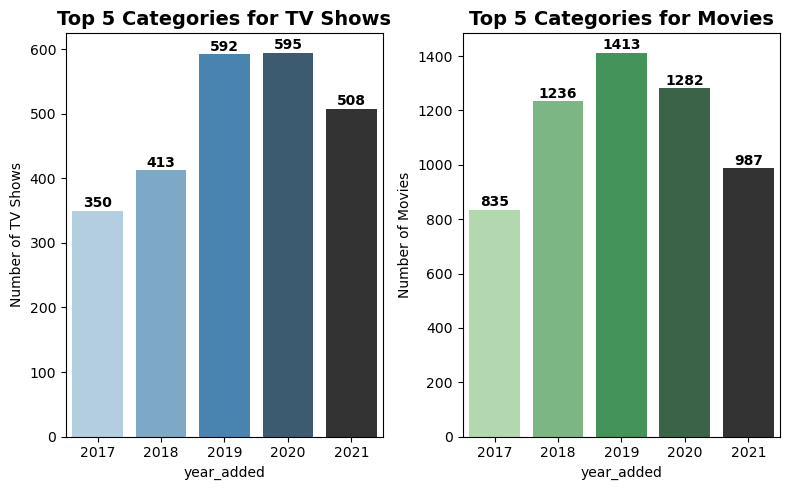

In [631]:
#Compares the top 5 years with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='year_added',title_col='title', x_col='year_added',y_col='Count',top_n=5)

## 📆 Year Added Highlights:

### ➤ Key Insight:
The platform saw a major spike in content additions between 2018 and 2021, especially in 2019 and 2020. **TV shows** peaked in 2020, likely due to increased streaming demand during the pandemic, while **movies** saw the highest growth in 2019, indicating a shift in content expansion strategy before global lockdowns.


🔢 Top 10 unique 'title' counts for 'release_year':
   release_year  unique_count
0          2018          1143
1          2017          1030
2          2019          1018
3          2020           953
4          2016           902
5          2021           587
6          2015           557
7          2014           351
8          2013           288
9          2012           237


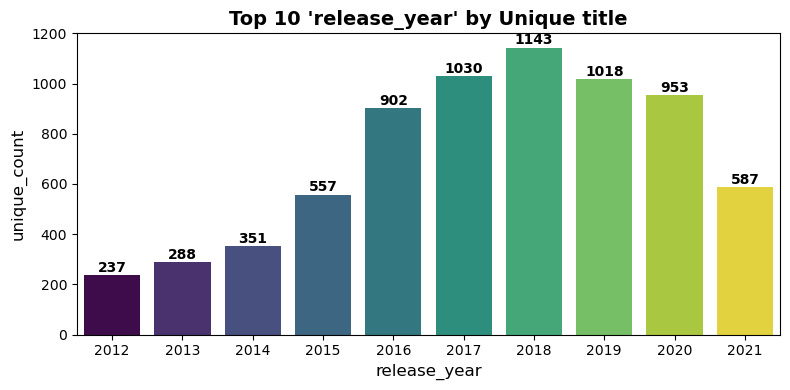

In [633]:
#Displays the top 10 release years with the most unique titles.
Analyze_column_distribution(df,column_name='release_year',target_col="title",top_n=10,exclude_values=[None],x_col='release_year',y_col="unique_count")

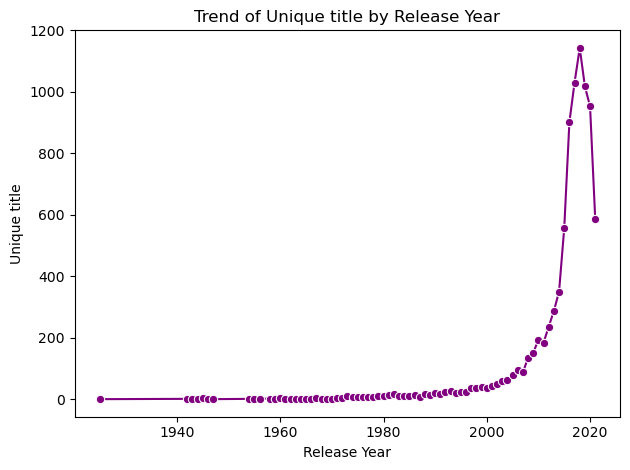

In [634]:
#Visualizes the trend of unique titles released over each year.
plot_line_for_column(df, "release_year", "title")

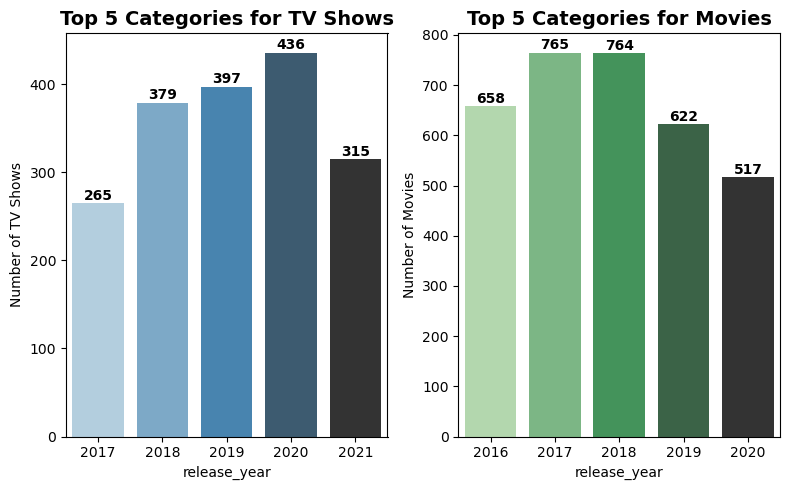

In [635]:
#Compares the top 5 release years with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='release_year',title_col='title', x_col='release_year',y_col='Count',top_n=5)

## 🎞️ Release Year Highlights:

### ➤ Key Insight:
Most content was released between 2016 and 2020, reflecting a focus on recent productions. **Movies** peaked in 2017–2018, while **TV shows** saw the highest releases in 2020, indicating a growing investment in episodic content amid rising streaming demand.

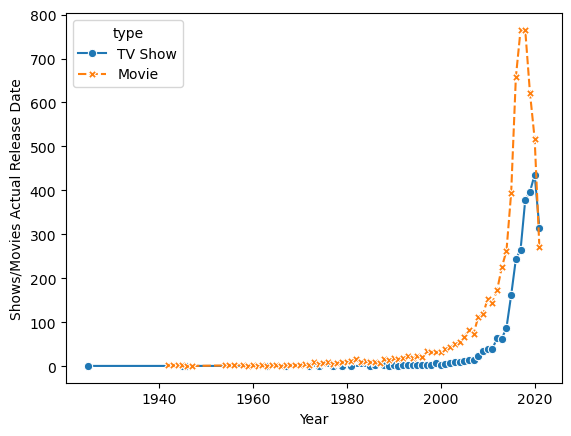

In [637]:
# Group by release_year and type to get unique titles count, and reset index
df_release_year_type = df.groupby(["release_year", "type"])["title"].nunique().reset_index()

# Now plot the lineplot using 'type' for hue and style
sns.lineplot(x='release_year', y='title', hue='type', style='type', markers=True, data=df_release_year_type)
plt.ylabel("Shows/Movies Actual Release Date")
plt.xlabel("Year")
plt.show()

## 📈 Release Trend Over the Years:
- This line plot shows the number of unique **TV Shows** and **Movies** released each year based on actual release dates.
- **Movies** rose sharply from 2010, peaking around 2018–2019 with over 750 titles, then dropped slightly after 2020.
- **TV Shows** increased steadily, peaking in 2020 with over 400 titles, likely due to the streaming boom during the pandemic.
- Pre-2000, both content types had minimal releases, reflecting limited archival data or a focus on newer content.

### ➤ Key Insight:
The platform focuses on modern content, particularly post-2015. **Movies** had an earlier growth, while **TV shows** rapidly gained traction by 2020, indicating a shift toward serialized, binge-worthy content to engage users.


🔢 Top 10 unique 'title' counts for 'rating':
  rating  unique_count
0  TV-MA          3202
1  TV-14          2142
2  TV-PG           863
3      R           798
4  PG-13           489
5  TV-Y7           334
6   TV-Y           305
7     PG           287
8   TV-G           220
9      G            41


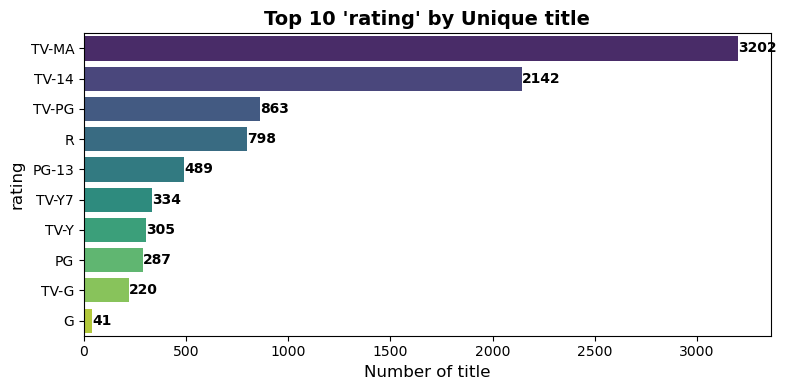

In [639]:
## Displays the top 10 ratings with the most unique titles, excluding 'NR' (Not Rated) entries.
Analyze_column_distribution(df,column_name='rating',target_col="title",top_n=10,exclude_values=['NR'],x_col="unique_count",y_col=None)

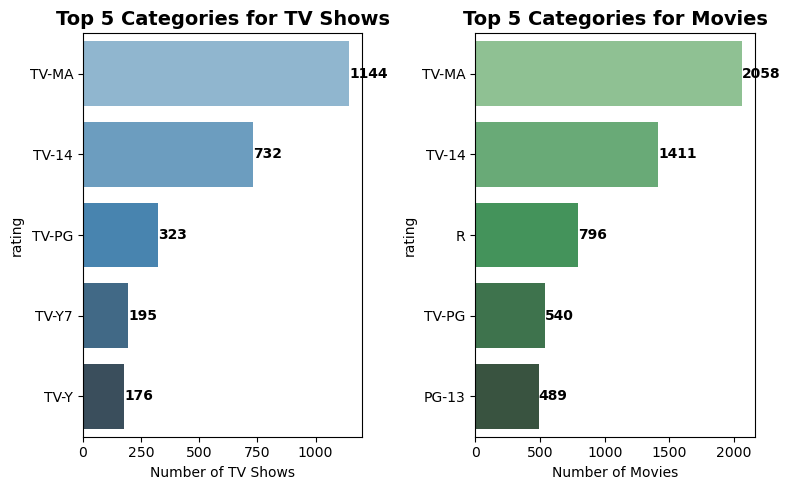

In [640]:
#Compares the top 5 ratings with the highest number of title additions in shows and movies, excluding 'NR' entries.
Analyze_top_categories(df_shows,df_movies,category_col='rating',title_col='title', x_col='Count',y_col='rating',exclude_values=['NR'],top_n=5)

## 🎯 Top Content Ratings on the Platform:
- **TV-MA and R** = Adult content
- **TV-14 and PG-13** = Teens and above
- **TV-PG and PG** = Family-friendly with guidance
- **TV-Y, TV-Y7, TV-G, G** = Child-appropriate

### ➤ Key Insight:
The platform primarily focuses on mature audience content across both **TV shows** and **movies**, while maintaining a balanced offering for teens and children, especially with **TV-PG**, **TV-Y7**, and **TV-Y** ratings.


🔢 Top 10 unique 'title' counts for 'duration':
    duration  unique_count
0     80-100          2219
1   1 Season          1791
2    100-120          1669
3    120-150           885
4      50-80           808
5  2 Seasons           425
6       1-50           287
7    150-200           221
8  3 Seasons           199
9  4 Seasons            95


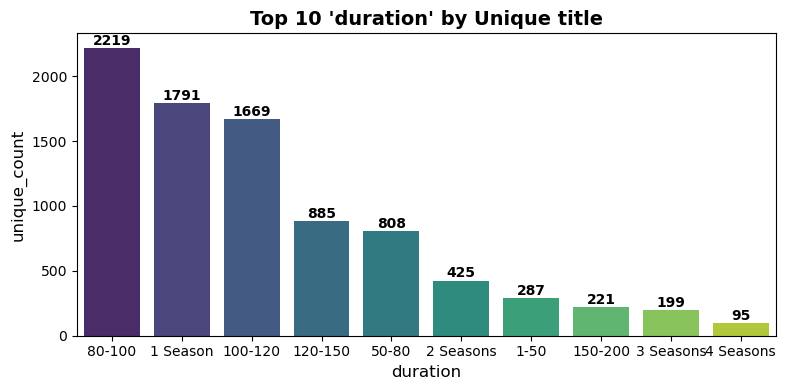

In [642]:
#Displays the top 10 durations (seasons) with the most unique titles, excluding entries with 0 seasons.
Analyze_column_distribution(df,column_name='duration',target_col="title",top_n=10,exclude_values=[0],x_col='duration',y_col="unique_count")

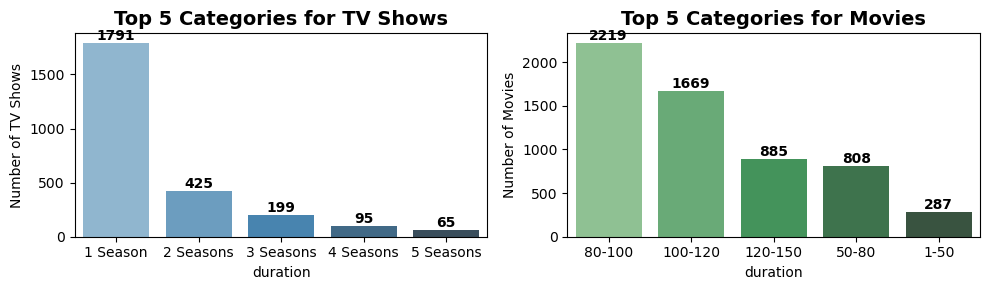

In [787]:
#Compares the top 5 durations (seasons) with the highest number of title additions in shows and movies, excluding entries with 0 seasons.
Analyze_top_categories(df_shows,df_movies,category_col='duration',title_col='title', y_col='Count',x_col='duration',exclude_values=[0],top_n=5)

## 🎞️ Duration Highlights:

### ➤ Key Insight:
Most titles cluster around **80–120 minutes** for **movies** and **1–3 seasons** for **TV shows**, indicating a preference for concise formats. However, the significant presence of shows with **5+ seasons** suggests enduring popularity and loyalty for long-running series.


🔢 Top 10 unique 'title' counts for 'listed_in':
                  listed_in  unique_count
0      International Movies          2731
1                    Dramas          2411
2                  Comedies          1669
3    International TV Shows          1350
4             Documentaries           869
5        Action & Adventure           852
6                 TV Dramas           761
7        Independent Movies           755
8  Children & Family Movies           638
9           Romantic Movies           615


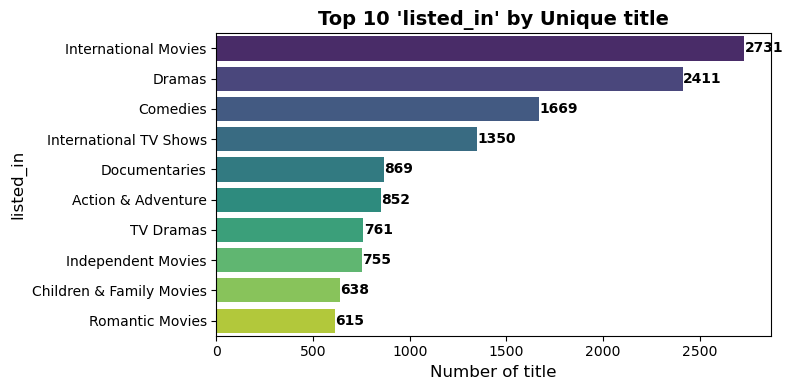

In [645]:
#Displays the top 10 categories (listed_in) with the most unique titles, excluding entries with no categories.
Analyze_column_distribution(df,column_name='listed_in',target_col="title",top_n=10,exclude_values=[None],x_col="unique_count",y_col=None)

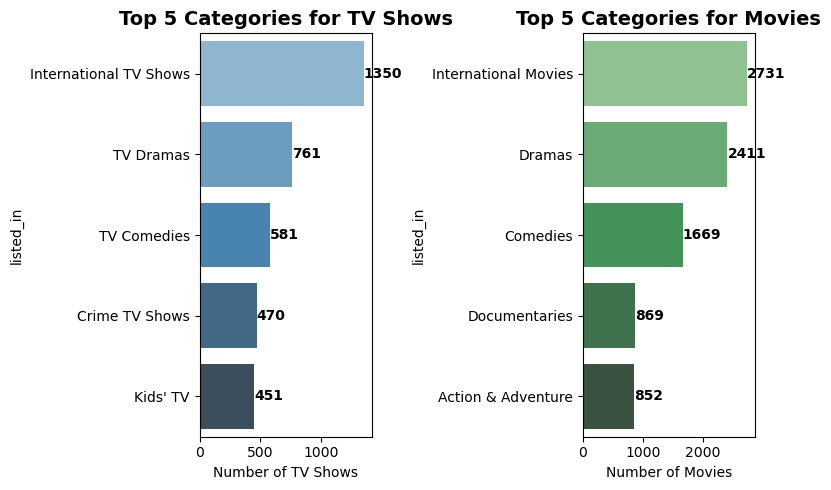

In [646]:
#Compares the top 5 categories with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='listed_in',title_col='title', x_col='Count',y_col='listed_in',top_n=5)

## 🎞️ Genre Distribution Highlights:

### Observation:
- **Movies**: The most common genres are **Dramas** (2411), **Comedies** (1669), and **International Movies** (2731), followed by **Documentaries** (869). These genres dominate, reflecting a strong focus on diverse global content and narratives.
- **TV Shows**: The leading genres are **International TV Shows** (1350), **TV Dramas** (761), and **TV Comedies** (581), with notable genres like **Docuseries** (395) and **Crime TV Shows** (470). TV shows have higher representation in genres like **Reality TV** (255) and **Kids' TV** (451).

### ➤ Key Insight:
The platform has a strong focus on **international movies**, **dramas**, and **comedies**, with these genres leading in unique titles. Other notable categories include **international TV shows** and **documentaries**. Genres like **action & adventure** and **romantic movies** have slightly smaller representation, showing a diverse yet concentrated content offering in popular genres. **Movies** are predominantly represented by **international films**, **dramas**, and **comedies**, with significant portions also in **action & adventure** and **documentaries**, appealing to varied tastes. **TV shows** are largely centered around **international series** and **dramas**, with an increasing focus on **serialized, binge-worthy content** that aligns with global streaming trends.

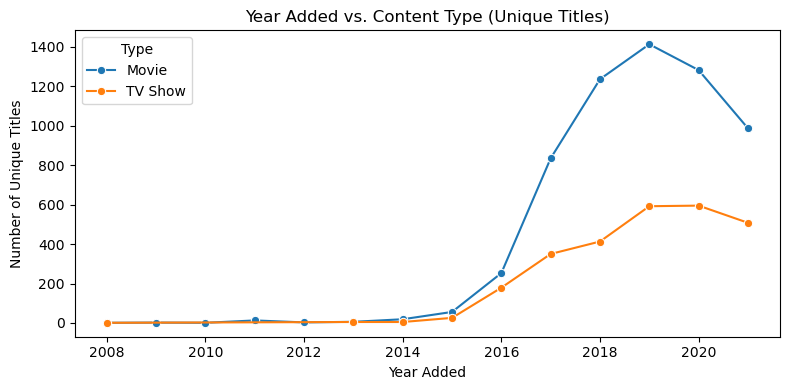

In [648]:
###Date Added vs. Type (TV Show vs Movie)

# Grouping by Year and Type and counting unique titles
type_trend_unique = df.groupby(['year_added', 'type'])['title'].nunique().reset_index(name='count')

# Plot
plt.figure(figsize=(8, 4))
sns.lineplot(data=type_trend_unique, x='year_added', y='count', hue='type', marker="o")
plt.title('Year Added vs. Content Type (Unique Titles)')
plt.xlabel('Year Added')
plt.ylabel('Number of Unique Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

## 🎥 Date Added vs. Type (TV Show vs Movie)

### Observation:
- Minimal content was added before **2015**.
- From **2016** onwards, both **Movies** and **TV Shows** saw a sharp, steady rise in unique titles.
- **Movies** consistently outnumber **TV Shows** in volume each year.
- **TV Shows** show strong growth from **2017**, peaking around **2020–2021**.

### ➤ Key Insight:
The platform has steadily ramped up content in both formats since **2016**. While **Movies** dominate in volume, the significant rise in **TV Shows** indicates a growing focus on episodic content, likely driven by binge-watching trends and long-term viewer engagement.

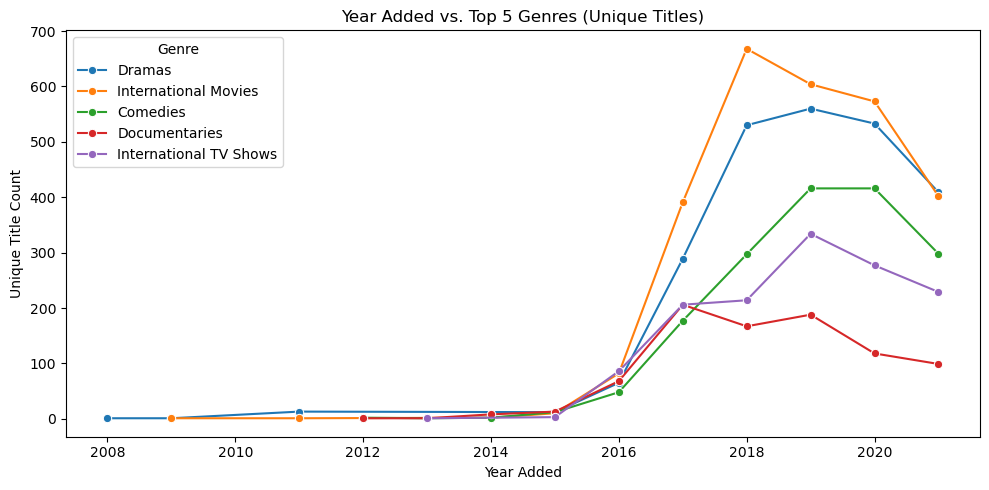

In [650]:
### Trend: Year Added vs. Top Genres

# Group by year and genre, count unique titles
genre_trend = df.groupby(['year_added', 'listed_in'])['title'].nunique().reset_index(name='count')

# Top 5 genres overall based on total unique titles
top_genres = genre_trend.groupby('listed_in')['count'].sum().nlargest(5).index

# Filter only top genres
genre_trend_top = genre_trend[genre_trend['listed_in'].isin(top_genres)]

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=genre_trend_top, x='year_added', y='count', hue='listed_in', marker='o')

plt.title('Year Added vs. Top 5 Genres (Unique Titles)')
plt.xlabel('Year Added')
plt.ylabel('Unique Title Count')
plt.legend(title='Genre')
plt.tight_layout()
plt.show()

## 🎯 Top Genre Trends on the Platform

### Observation:
- **Dramas**: Consistent growth since **2016**, reflecting increasing demand.
- **International Movies**: Rising steadily, indicating a shift toward global content.
- **International TV Shows**: Significant spike post-2016, catering to a diverse, non-English-speaking audience.
- **Documentaries**: Fluctuations, with spikes in **2016-2017**, possibly tied to events or trends.
- **Fluctuating Genres**: **Comedies** and **Action & Adventure** show variable trends, likely influenced by changing viewer preferences.

### ➤ Key Insight:
The platform has focused on expanding its **international** and **drama** offerings, with significant growth in non-English content, while maintaining flexibility in genres like **comedies** and **action**.

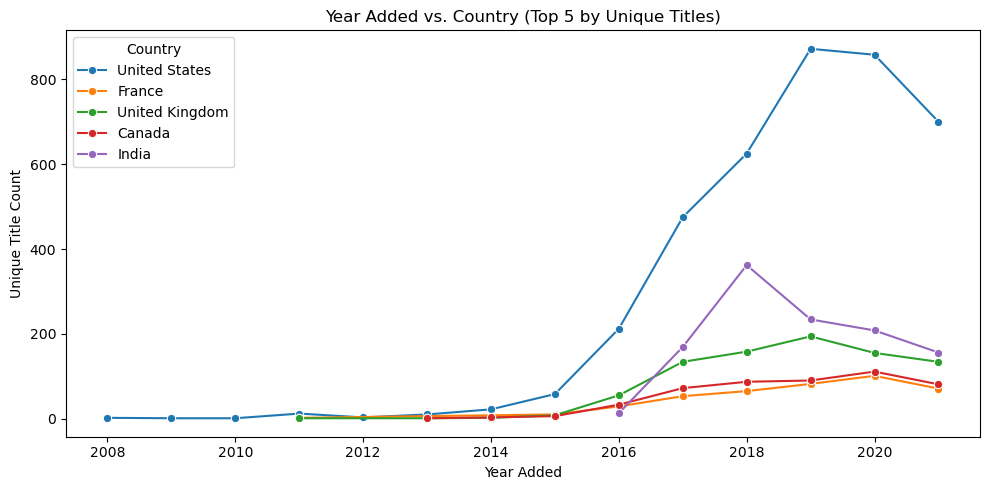

In [652]:
### Trend:  Date Added vs. Country

df_clean = df[df['country'] != 'Unknown Country']
# Group by year_added and country, get unique titles
country_trend = df_clean.groupby(['year_added', 'country'])['title'].nunique().reset_index(name='count')

# Get top 5 countries with highest total unique titles added
top_countries = country_trend.groupby('country')['count'].sum().nlargest(5).index

# Filter only for top countries
country_trend_top = country_trend[country_trend['country'].isin(top_countries)]

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=country_trend_top, x='year_added', y='count', hue='country', marker='o')
plt.title('Year Added vs. Country (Top 5 by Unique Titles)')
plt.xlabel('Year Added')
plt.ylabel('Unique Title Count')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

## 🌍 Date Added vs. Country (Top 5 by Unique Titles)

### Observation:
- **United States** consistently leads in content additions across all years.
- **India** shows a dramatic rise starting in **2017**, peaking in **2018**.
- **United Kingdom**, **France**, and **Canada** show steady growth with minor year-to-year fluctuations.
- All top 5 countries have notable spikes from **2016** onwards, reflecting global expansion.

### ➤ Key Insight:
The platform significantly scaled its international content after **2016**. While the **U.S.** remains dominant, countries like **India** and the **UK** emerged as major contributors, indicating a strategic focus on regional and globally diverse content offerings.

              release_year  year_added
release_year      1.000000    0.110242
year_added        0.110242    1.000000


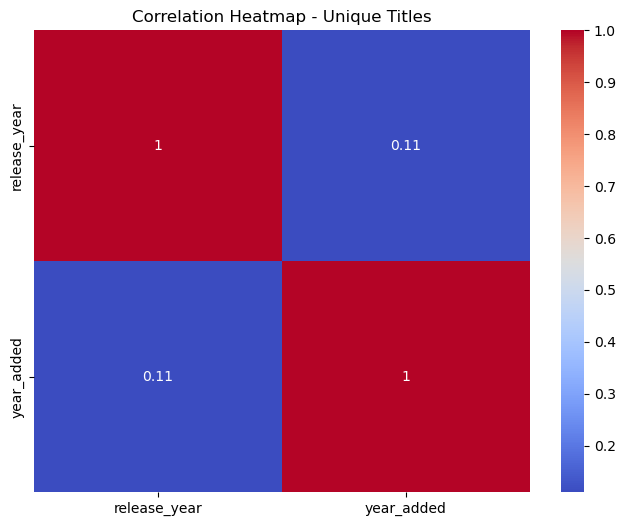

In [654]:
# Step 1: Group by unique titles and aggregate the necessary columns
df_unique_titles = df.groupby('title').agg({
    'release_year': 'first',  # or any other aggregation like mean
    'year_added': 'first'     # or any other aggregation
}).reset_index()

# Step 2: Calculate the correlation matrix for the unique titles
correlation_matrix = df_unique_titles[['release_year', 'year_added']].corr()
print(correlation_matrix)
# Step 3: Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap - Unique Titles")
plt.show()


## Insight: 
The correlation between **release year** and **year added** is weak (**0.11**), indicating that the timing of adding titles to the platform is not strongly influenced by their release year.

              release_year  year_added
release_year      1.000000    0.378817
year_added        0.378817    1.000000


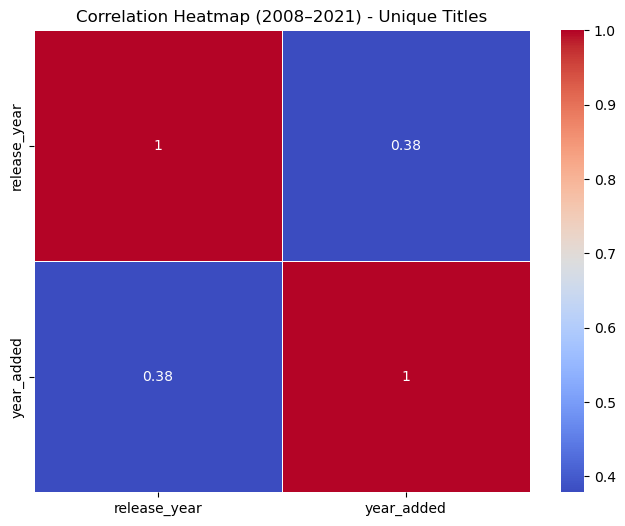

In [656]:
# Step 1: Group by unique titles and aggregate
df_unique_titles = df.groupby('title').agg({
    'release_year': 'first',
    'year_added': 'first'
}).reset_index()

# Step 2: Filter for years between 2008 and 2021
filtered_df = df_unique_titles[
    (df_unique_titles['release_year'].between(2008, 2021)) &
    (df_unique_titles['year_added'].between(2008, 2021))
]

# Step 3: Compute correlation matrix
correlation_matrix = filtered_df[['release_year', 'year_added']].corr()
print(correlation_matrix)

# Step 4: Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap (2008–2021) - Unique Titles")
plt.show()

## 📊 Correlation Insight (2008–2021)

### ➤ Key Insight:
When focusing on titles released and added between **2008** and **2021**, the correlation between **release_year** and **year_added** increases to **0.38**.  
This suggests a moderate relationship, meaning **newer titles** are more likely to be added to Netflix soon after their release, reflecting a stronger focus on **recent content**.

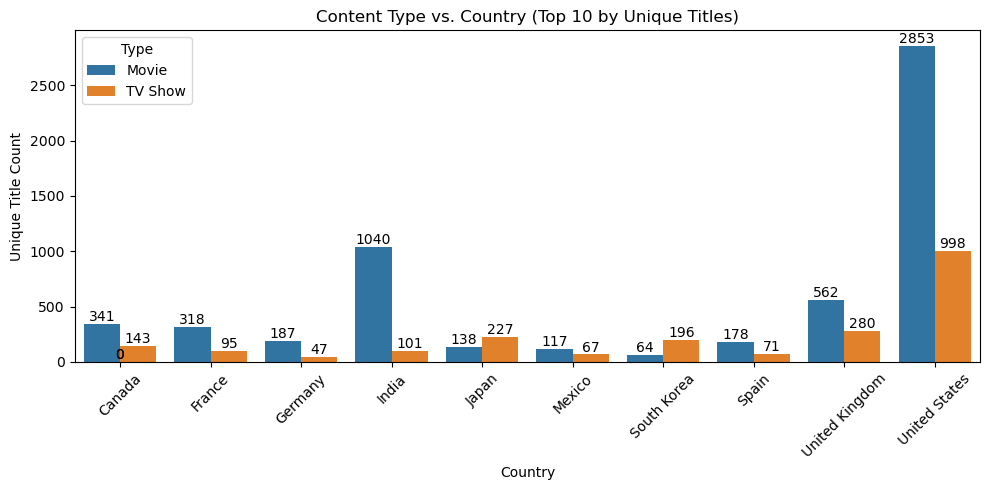

In [658]:
### Content Type vs. Country (Top 10 by Unique Titles)


df_clean_country = df[df['country'] != 'Unknown Country']

# Group by country and type, count unique titles
country_type_trend = df_clean_country.groupby(['country', 'type'])['title'].nunique().reset_index(name='count')

# Get top 10 countries by total unique titles
top_countries_ct = country_type_trend.groupby('country')['count'].sum().nlargest(10).index

# Filter only top countries
country_type_top = country_type_trend[country_type_trend['country'].isin(top_countries_ct)]

# Plot grouped bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=country_type_top, x='country', y='count', hue='type')
plt.title('Content Type vs. Country (Top 10 by Unique Titles)')
plt.xlabel('Country')
plt.ylabel('Unique Title Count')
plt.legend(title='Type')
plt.xticks(rotation=45)

# Adding the count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 🌍 Content Type vs. Country (Top 10 by Unique Titles)

### Observation:
- **United States** dominates both **Movie** and **TV Show** categories, with the highest number of unique titles in both types.
- **Canada** follows, with a significantly higher count of unique **Movies** than **TV Shows**.
- **India** has a high volume of **Movies** but fewer **TV Shows** compared to other countries in the top 10.
- **United Kingdom**, **France**, and **Germany** show a balanced split between **Movies** and **TV Shows**, with **Movies** generally leading.
- **Japan** stands out with a higher count of unique **TV Shows** than **Movies**.

### ➤ Key Insight:
The **United States** leads across both **Movie** and **TV Show** content, reflecting its global dominance in entertainment production. Other countries, like **Canada**, **India**, and **Japan**, show strong presences in specific content types, such as **Movies** or **TV Shows**, indicating distinct content creation trends.

In [660]:
# Filter data by country for Movies
df_movies_us = df_movies[df_movies['country'] == 'United States']
df_movies_in = df_movies[df_movies['country'] == 'India']
df_movies_uk = df_movies[df_movies['country'] == 'United Kingdom']
df_movies_sk = df_movies[df_movies['country'] == 'South Korea']
df_movies_jp = df_movies[df_movies['country'] == 'Japan']

# Filter data by country for TV Shows
df_shows_us = df_shows[df_shows['country'] == 'United States']
df_shows_in = df_shows[df_shows['country'] == 'India']
df_shows_uk = df_shows[df_shows['country'] == 'United Kingdom']
df_shows_sk = df_shows[df_shows['country'] == 'South Korea']
df_shows_jp =  df_shows[df_shows['country'] == 'Japan']

## Function: `Analyze_column_distribution_by_country`

### Purpose:
Analyzes and visualizes the distribution of unique titles in a given column (e.g., genre, rating) across TV shows or movies for five countries: the US, India, the UK, South Korea, and Japan.

### Parameters:
- **df_us, df_in, df_uk, df_sk, df_jp (DataFrames)**: DataFrames for each country (US, India, UK, South Korea, Japan).
- **column_name (str)**: The column to analyze (e.g., 'genre', 'rating').
- **media_type (str)**: Type of media ('tv_shows' or 'movies').
- **exclude_values (list, optional)**: List of values to exclude from the analysis (e.g., "Unknown").

### Output:
- A 2x3 grid of bar charts comparing the top 10 unique titles across the five countries based on the selected column.

In [662]:
def Analyze_column_distribution_by_country(df_us, df_in, df_uk, df_sk, df_jp, column_name, media_type, exclude_values=None):
    import seaborn as sns
    import matplotlib.pyplot as plt

    def clean_df(df):
        df_clean = df.dropna(subset=[column_name])
        if exclude_values:
            df_clean = df_clean[~df_clean[column_name].isin(exclude_values)]
        return df_clean

    # Clean all five country DataFrames
    df_us = clean_df(df_us)
    df_in = clean_df(df_in)
    df_uk = clean_df(df_uk)
    df_sk = clean_df(df_sk)
    df_jp = clean_df(df_jp)

    # Group, count unique titles, and take top 10
    us_column_counts = (df_us.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))
    in_column_counts = (df_in.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))
    uk_column_counts = (df_uk.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))
    sk_column_counts = (df_sk.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))
    jp_column_counts = (df_jp.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))

    # Set up color palettes
    viridis_palette_us = sns.color_palette("viridis", len(us_column_counts))
    viridis_palette_in = sns.color_palette("viridis", len(in_column_counts))
    viridis_palette_uk = sns.color_palette("viridis", len(uk_column_counts))
    viridis_palette_sk = sns.color_palette("viridis", len(sk_column_counts))
    viridis_palette_jp = sns.color_palette("viridis", len(jp_column_counts))

    # # Print counts (optional)
    # print("US:\n", us_column_counts, "\n")
    # print("India:\n", in_column_counts, "\n")
    # print("UK:\n", uk_column_counts, "\n")
    # print("South Korea:\n", sk_column_counts, "\n")
    # print("Japan:\n", jp_column_counts, "\n")

    # Plotting
    plt.figure(figsize=(18, 12))

    plt.subplot(2, 3, 1)
    sns.barplot(data=us_column_counts, x=column_name, y='title', palette=viridis_palette_us,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - US')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.subplot(2, 3, 2)
    sns.barplot(data=in_column_counts, x=column_name, y='title', palette=viridis_palette_in,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - India')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.subplot(2, 3, 3)
    sns.barplot(data=uk_column_counts, x=column_name, y='title', palette=viridis_palette_uk,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - UK')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.subplot(2, 3, 4)
    sns.barplot(data=sk_column_counts, x=column_name, y='title', palette=viridis_palette_sk,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - South Korea')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.subplot(2, 3, 5)
    sns.barplot(data=jp_column_counts, x=column_name, y='title', palette=viridis_palette_jp,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - Japan')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.tight_layout(pad=4.0)
    plt.show()

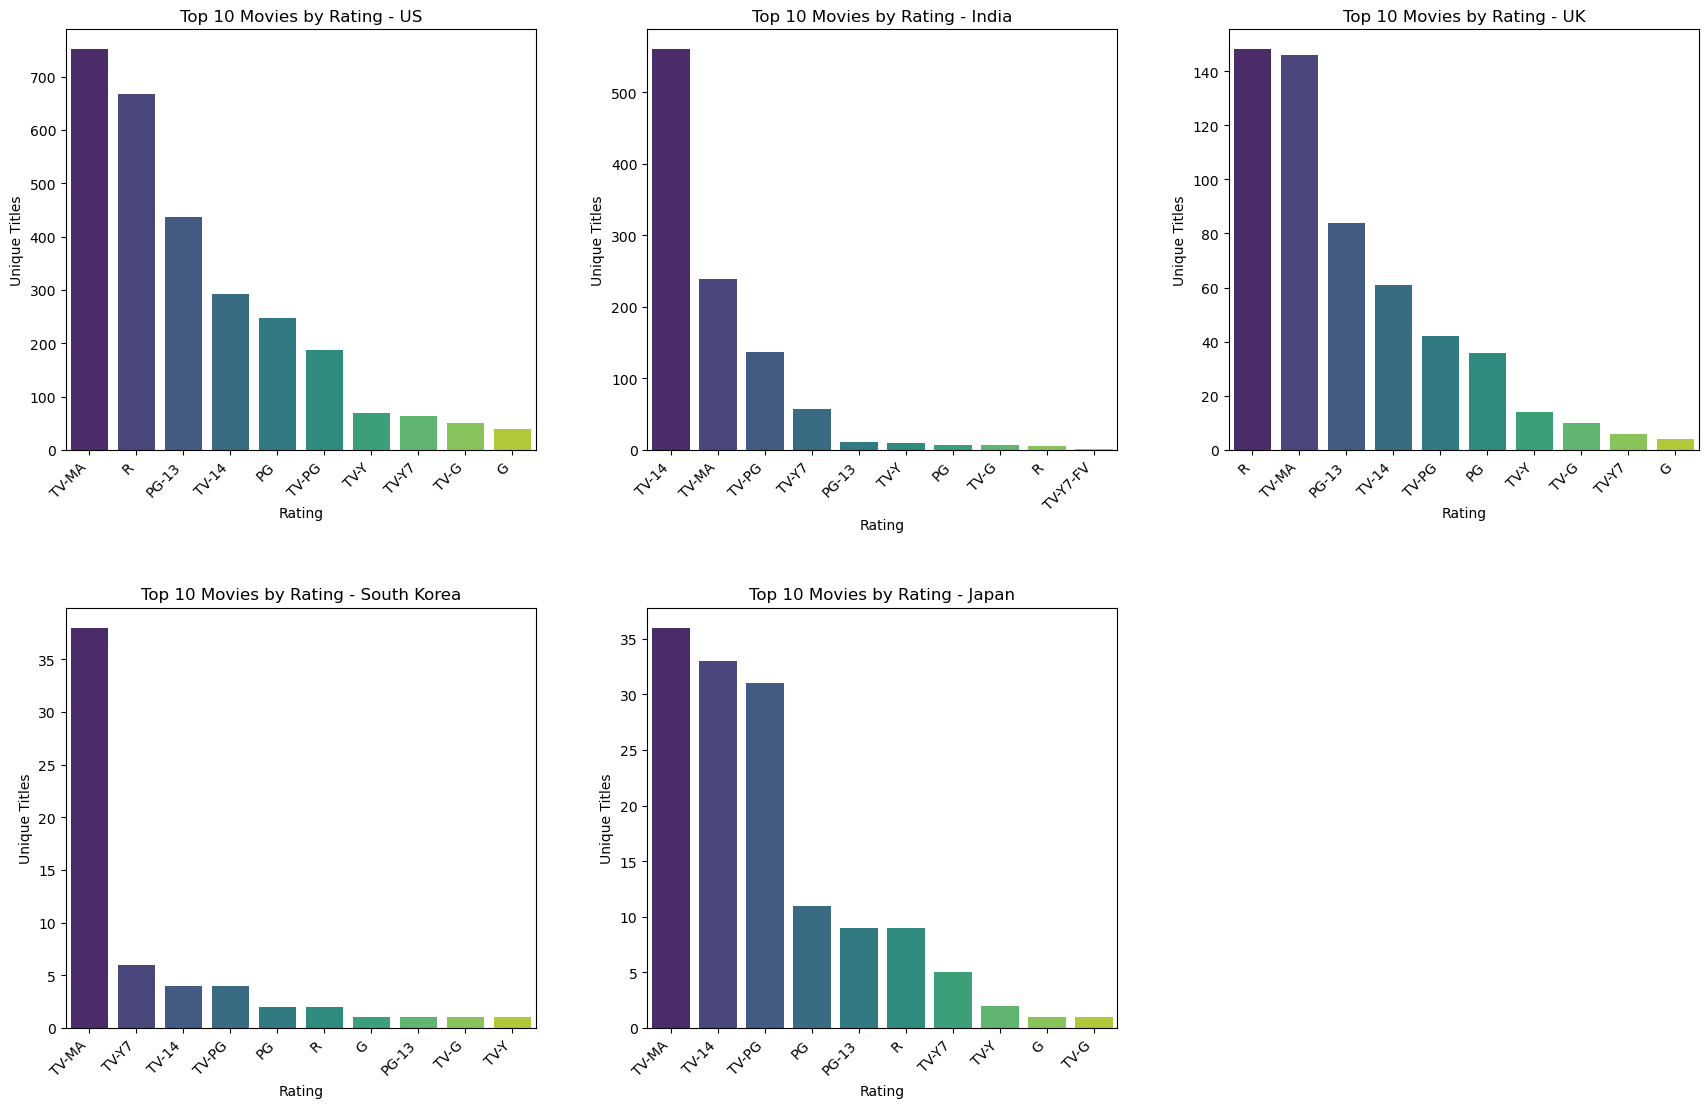

In [663]:
# For movies based on 'rating':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp, column_name='rating', media_type='movies',exclude_values=['NR'])


## 🎬 Movie Rating Summary by Country

### Observations:
- **US**: Diverse ratings, with a strong presence of TV-MA, R, PG-13, and TV-14.
- **India**: Predominantly TV-14 and TV-MA.
- **UK**: Mix of TV-MA, R, PG-13, and TV-PG.
- **South Korea**: Primarily TV-MA, limited diversity.
- **Japan**: Focus on TV-MA, TV-14, and TV-PG, with some PG and R ratings.

### ➤ Key Insights:
- **US**: Offers a wide variety of ratings, appealing to a broad audience, from family-friendly (TV-Y) to mature content (TV-MA).
- **India**: Focuses mainly on mature and teen/adult content (TV-14, TV-MA), with less emphasis on child-friendly or general content.
- **UK**: Balanced representation across different ratings, with a good spread of content for both younger and adult viewers.
- **South Korea**: Strong focus on adult content (TV-MA), with limited content for younger audiences.
- **Japan**: Strong representation of TV-MA and TV-14, catering mostly to a more mature audience, but with some content for all age groups.

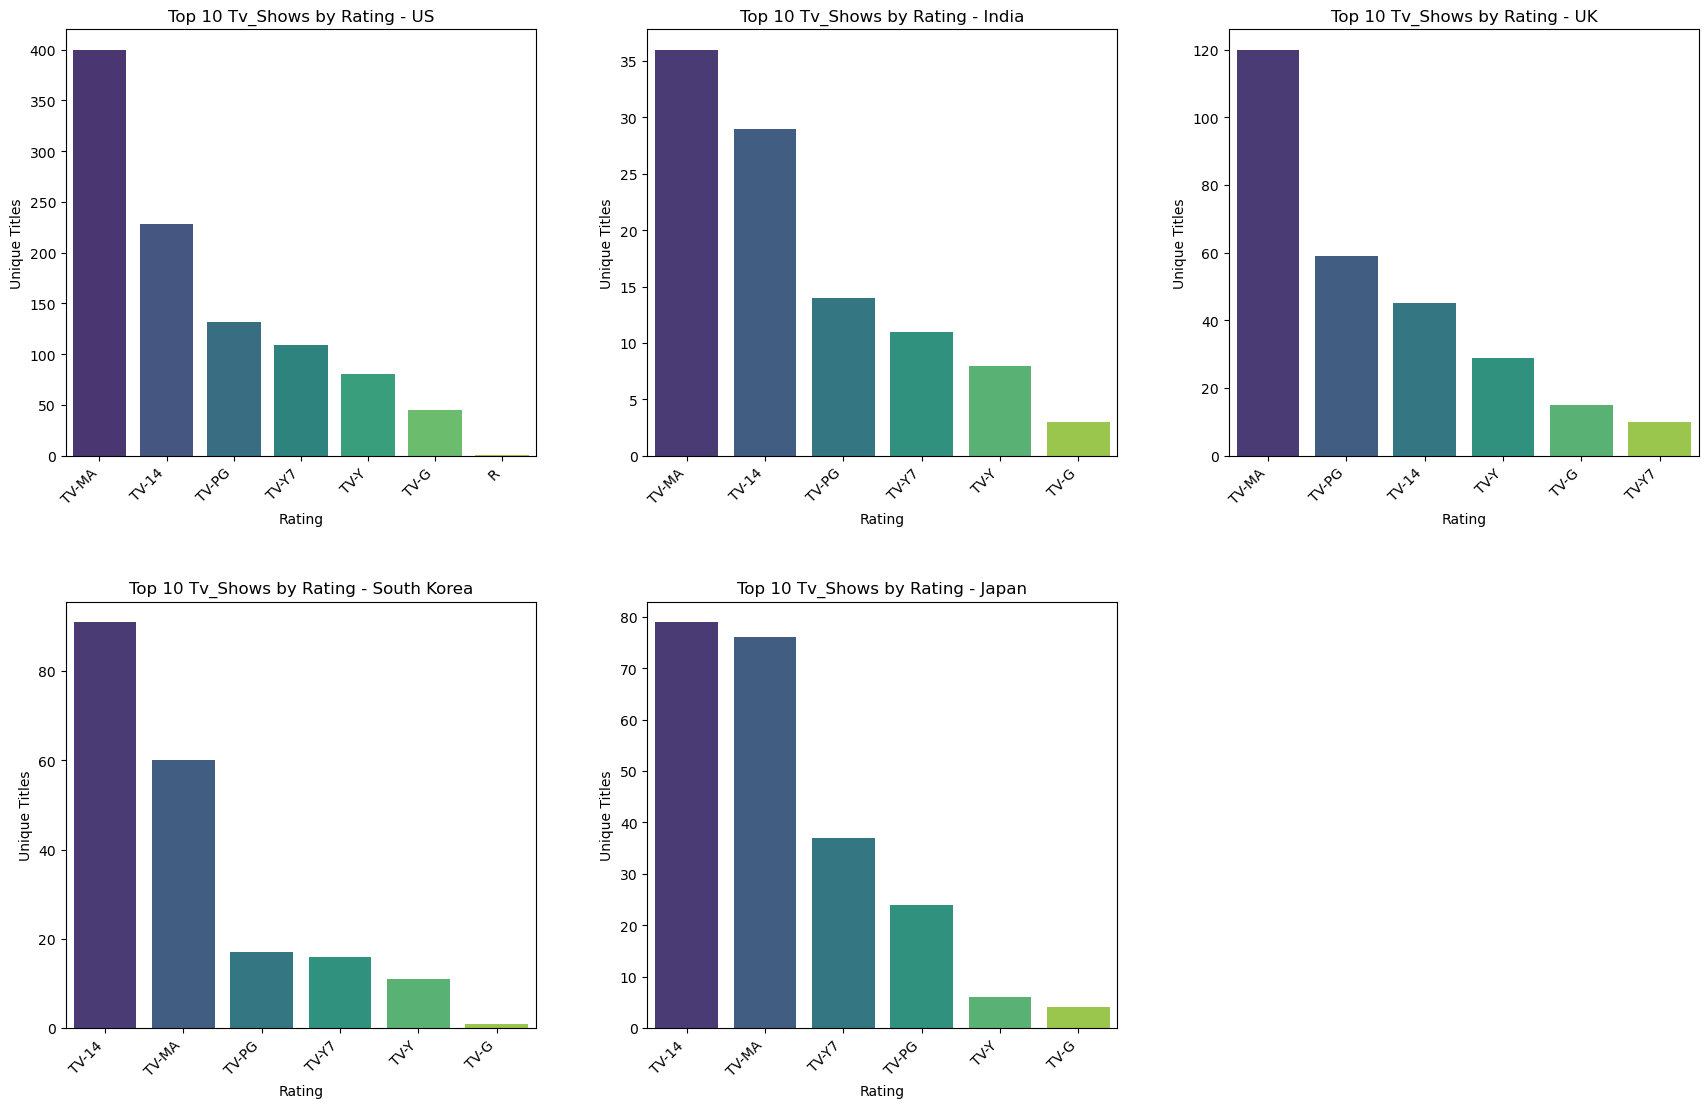

In [665]:
# For TV shows based on 'rating':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_sk,df_shows_jp, column_name='rating', media_type='tv_shows',exclude_values=['NR'])

## 🎬 TV Show Rating Summary by Country

### Observations:
- **US**: Dominated by TV-MA, TV-14, and TV-PG. TV-Y7 and TV-Y also present.
- **India**: Primarily TV-MA and TV-14, with some TV-PG and TV-Y7.
- **UK**: TV-MA, TV-PG, and TV-14 are the top ratings, with TV-Y and TV-G having a smaller presence.
- **South Korea**: Primarily TV-14 and TV-MA, with some TV-PG and TV-Y7.
- **Japan**: TV-14 and TV-MA dominate, with a fair amount of TV-Y7 and TV-PG.

### ➤ Key Insights:
- **US**: A wide variety of ratings, catering to multiple age groups, with a strong emphasis on adult content (TV-MA, TV-14) and family-friendly options (TV-PG, TV-Y7).
- **India**: Similar to the US but with a heavier focus on mature content (TV-MA, TV-14) and fewer family ratings.
- **UK**: A balanced range of content, with a focus on TV-MA and TV-PG, indicating a mix of adult and family-friendly options.
- **South Korea**: A more limited selection of ratings, with a strong focus on TV-14 and TV-MA, catering mostly to older audiences.
- **Japan**: Like South Korea, with a preference for mature ratings (TV-MA, TV-14) and a notable presence of TV-Y7 for younger viewers.

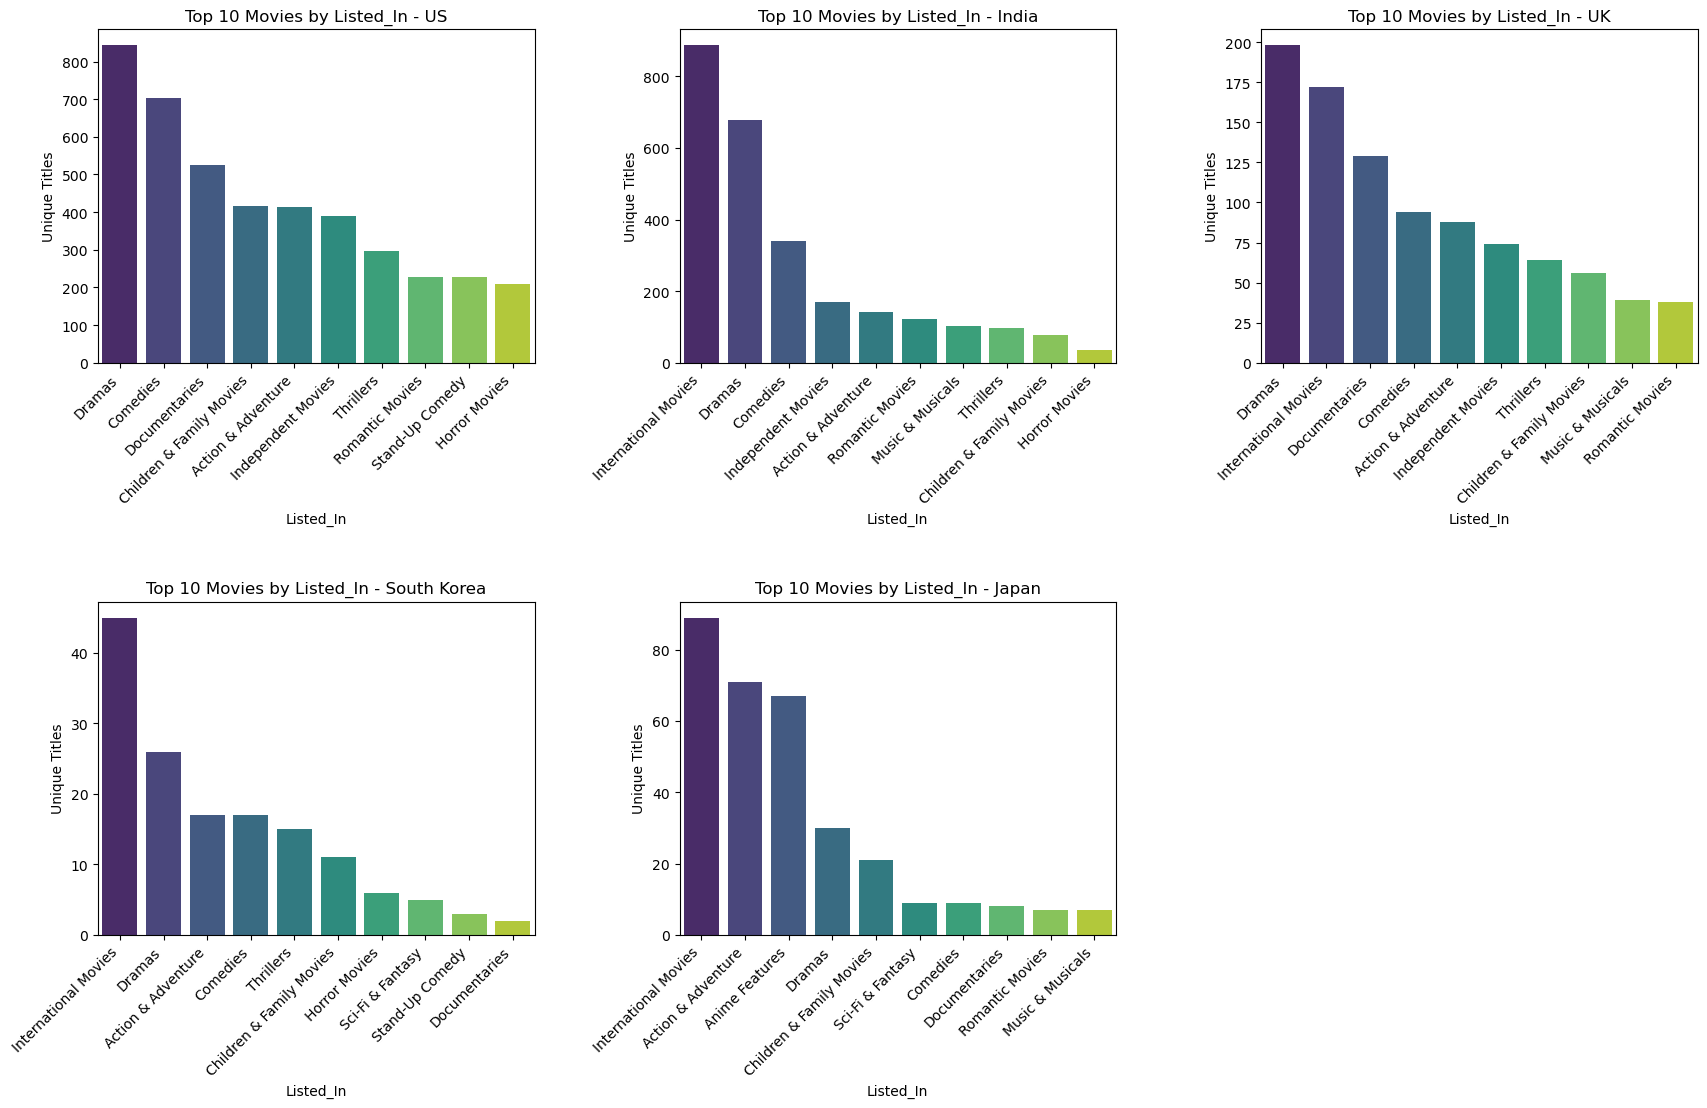

In [667]:
# For movies based on 'listed_in':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp, column_name='listed_in', media_type='movies')


## 🎬 Movie Genre Distribution by Country

### Observations:
- **US**: Dominated by Dramas, Comedies, Documentaries, and Children & Family Movies.
- **India**: Predominantly International Movies, Dramas, and Comedies.
- **UK**: Focus on Dramas, International Movies, and Documentaries.
- **South Korea**: Primarily International Movies and Dramas.
- **Japan**: Emphasis on International Movies, Action & Adventure, and Anime Features.

### ➤ Key Insights:
- **US**: Broad genre variety with strong family and drama content.
- **India**: Focus on international and dramatic films.
- **UK**: Niche genres, with a focus on dramas and documentaries.
- **South Korea**: International and drama-focused.
- **Japan**: Predominantly international and anime genres.

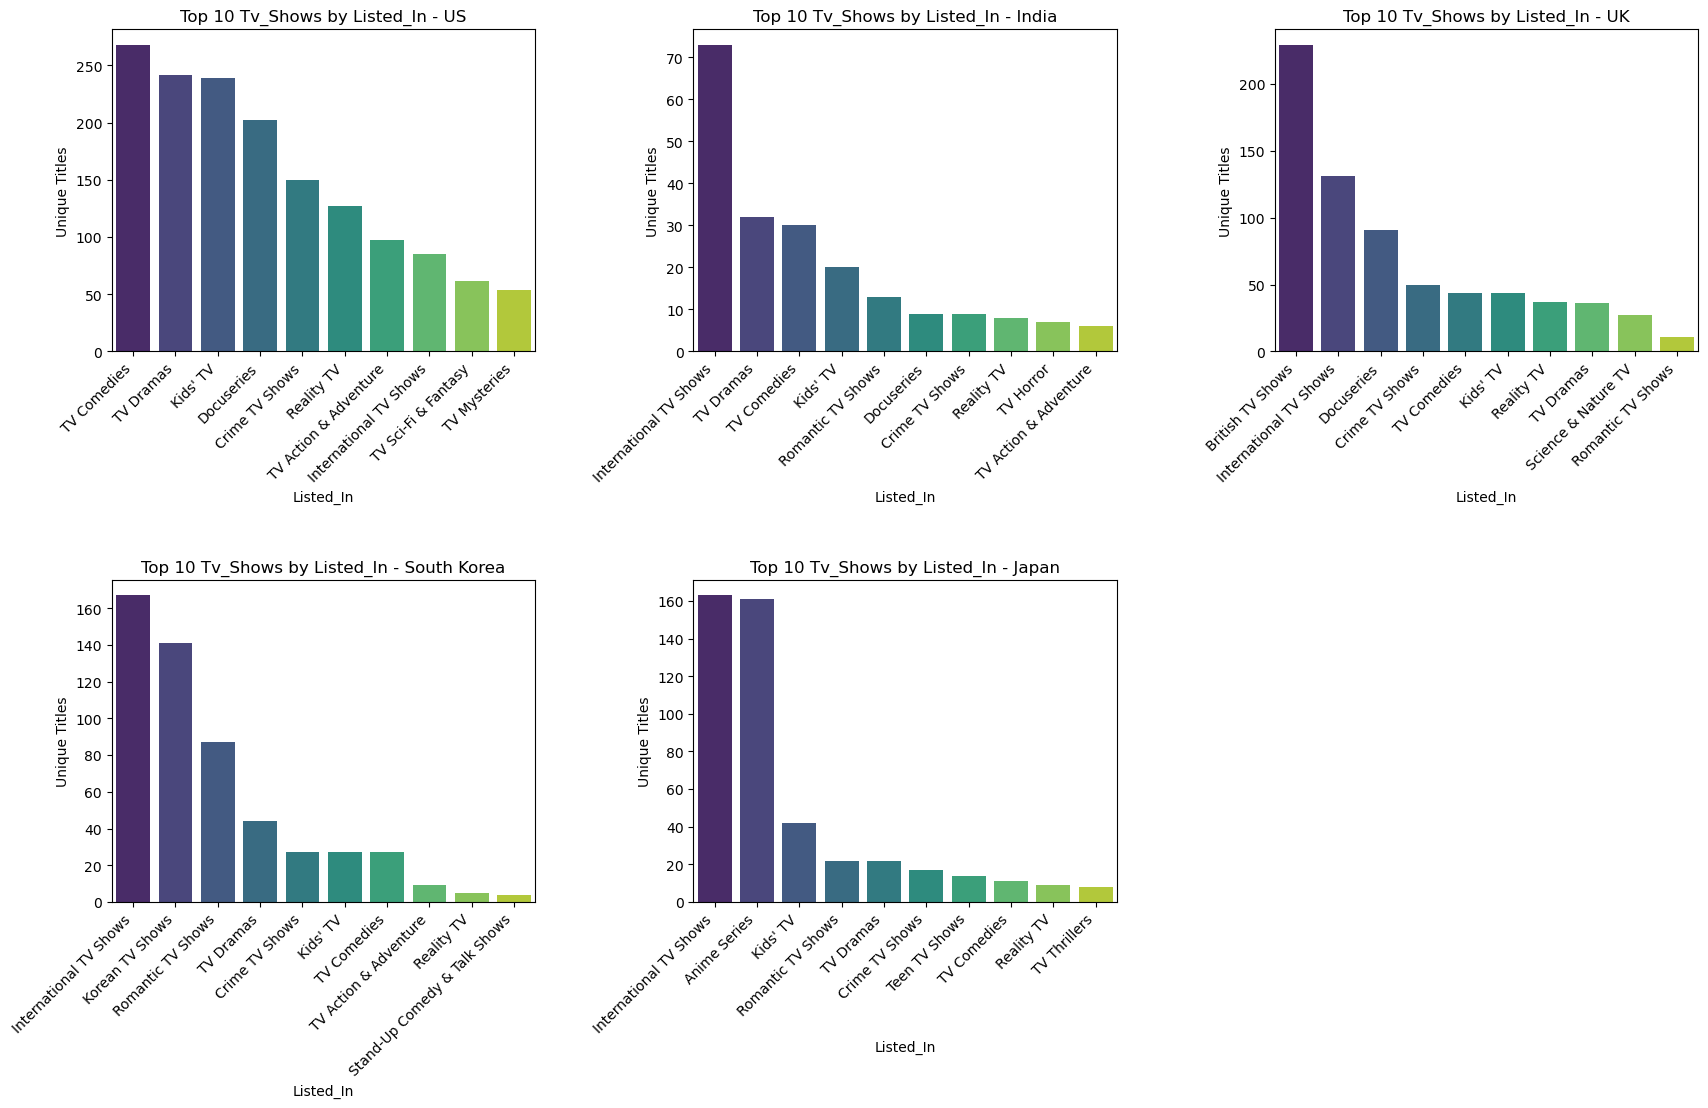

In [669]:
# For TV shows based on 'listed_in':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_sk,df_shows_jp, column_name='listed_in', media_type='tv_shows')

## 🎬 TV Show Genre Distribution by Country

### Observations:
- **US**: Dominated by TV Comedies, TV Dramas, Kids' TV, and Docuseries.
- **India**: Primarily International TV Shows, TV Dramas, and TV Comedies.
- **UK**: Focus on British TV Shows, International TV Shows, and Docuseries.
- **South Korea**: Strong presence of International TV Shows, Korean TV Shows, and Romantic TV Shows.
- **Japan**: Predominantly International TV Shows, Anime Series, and Kids' TV.

### ➤ Key Insights:
- **US**: Diverse genres with a strong focus on comedies, dramas, and kids' content.
- **India**: Focus on international and drama TV shows.
- **UK**: More British and international content, with a strong docuseries presence.
- **South Korea**: Korean TV Shows and romantic genres are notable, with international content as a significant part.
- **Japan**: Heavy focus on anime and international TV shows.

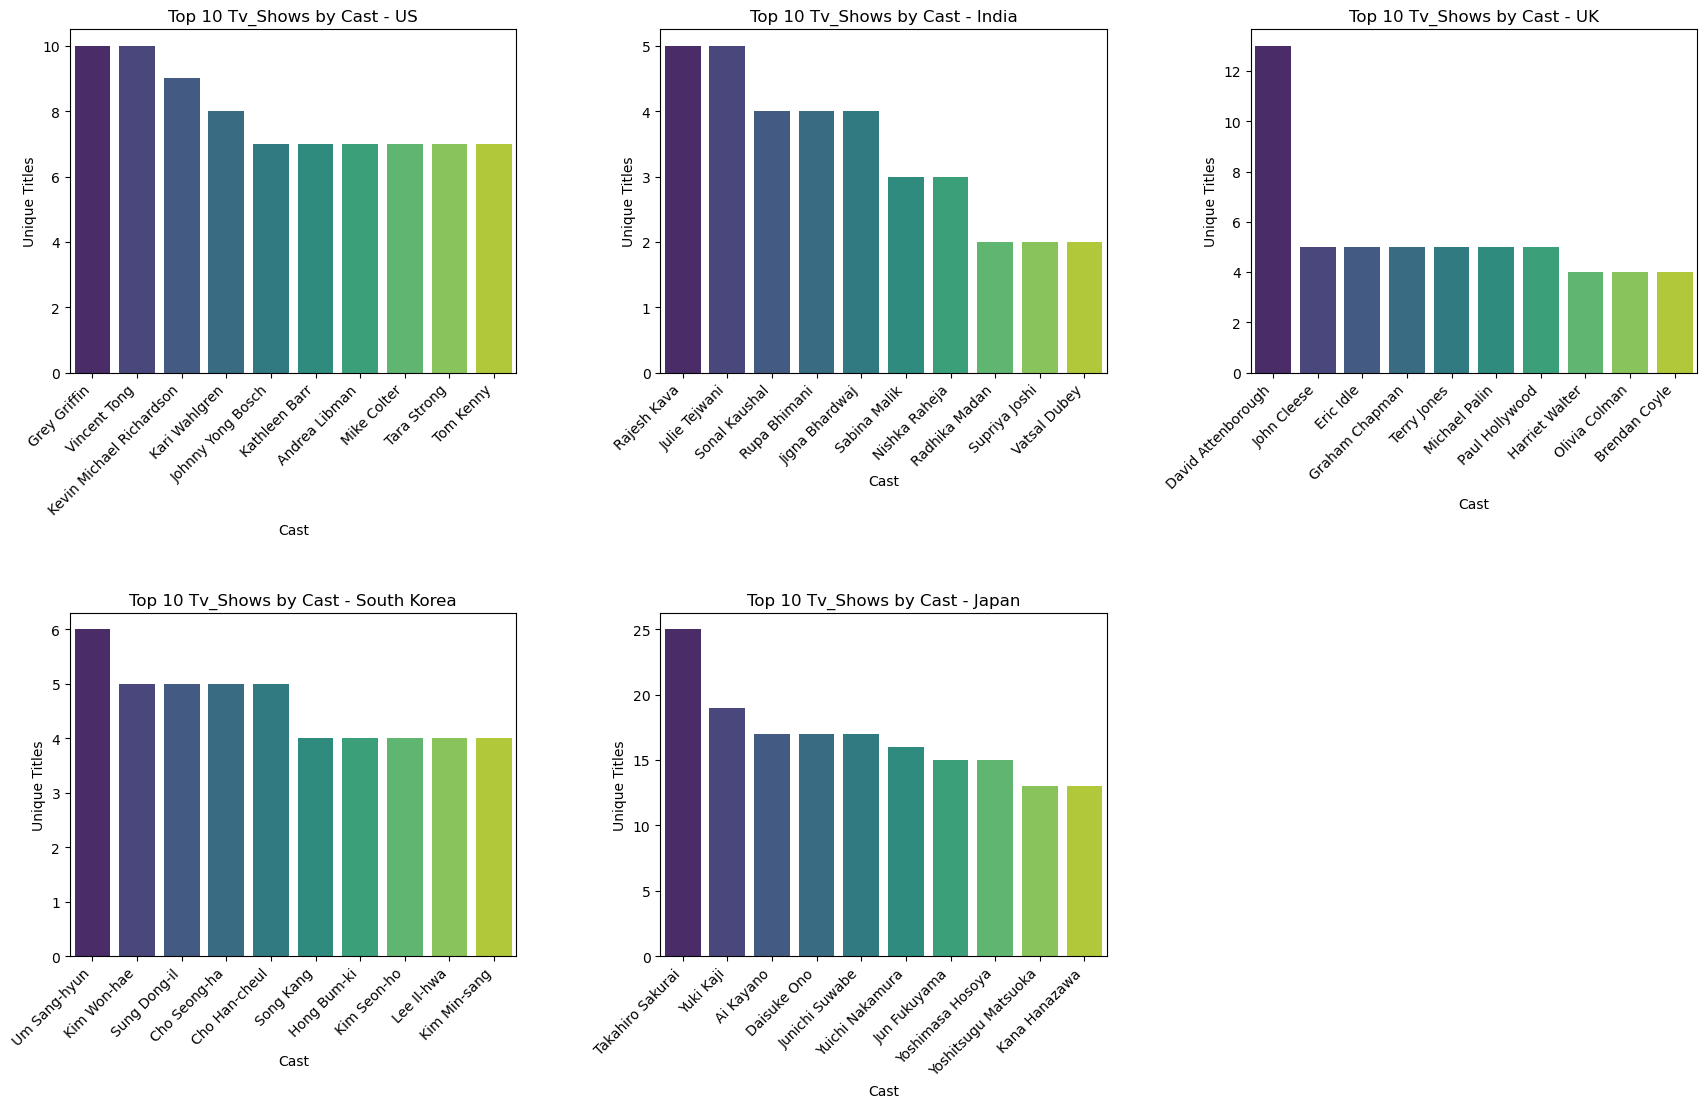

In [671]:
# For tv_shows based on 'cast':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_sk,df_shows_jp, column_name='cast', media_type='tv_shows',exclude_values=['Unknown Actor'])

## 🎬 TV Show Cast Distribution by Country

### Observations:
- **US**: Features a range of prominent voice actors, with Grey Griffin and Vincent Tong leading the cast.
- **India**: A mix of voice actors, with Rajesh Kava and Julie Tejwani having notable roles.
- **UK**: Known for iconic figures like David Attenborough, with a strong presence of British TV personalities.
- **South Korea**: Includes a mix of veteran actors like Um Sang-hyun and Kim Won-hae.
- **Japan**: Dominated by popular voice actors, especially in anime, with Takahiro Sakurai and Yuki Kaji being highly notable.

### ➤ Key Insights:
- **US**: Strong presence of voice actors, particularly in animated content.
- **India**: Focus on voice talent for local shows.
- **UK**: Emphasis on well-known TV personalities and documentary narrators.
- **South Korea**: A mixture of popular domestic actors in TV shows.
- **Japan**: Predominantly voice actors, especially those involved in anime series.

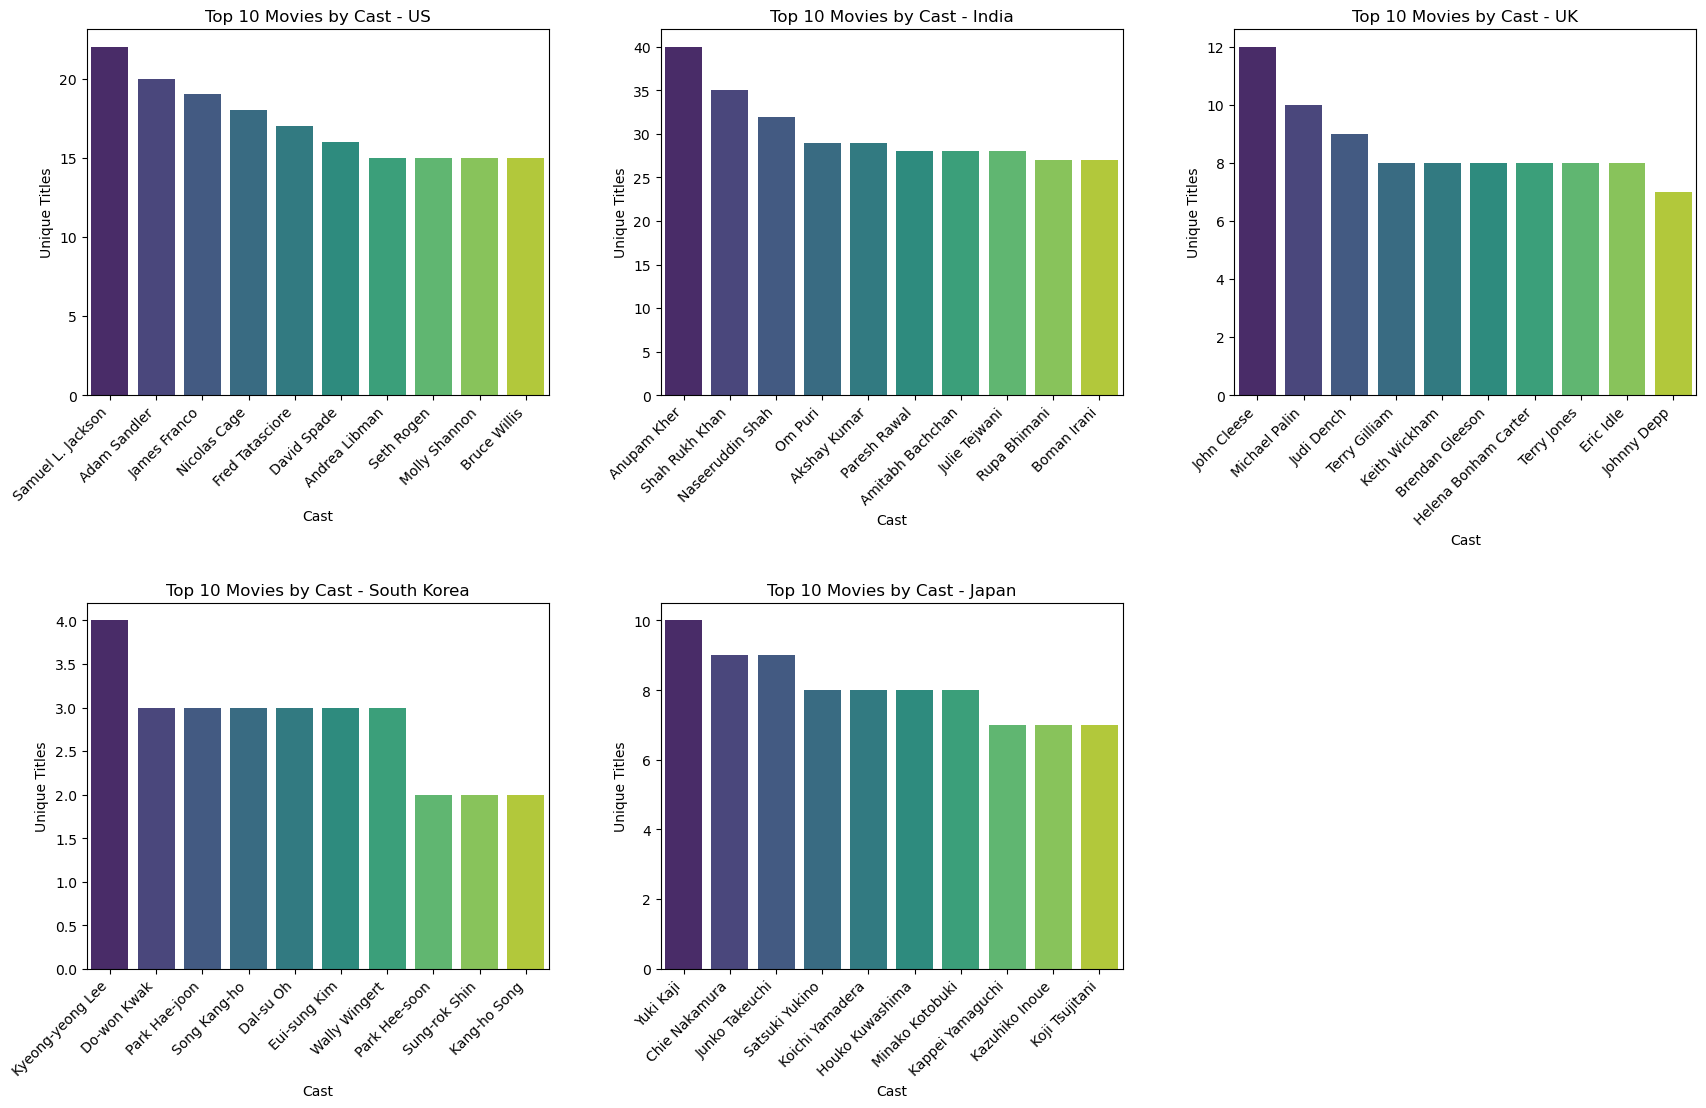

In [673]:
# For movies based on 'cast':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp, column_name='cast', media_type='movies',exclude_values=['Unknown Actor'])

## 🎬 Movie Cast Distribution by Country

### Observations:
- **US**: Features iconic actors such as Samuel L. Jackson, Adam Sandler, and Nicolas Cage, dominating the cast list.
- **India**: Well-known Bollywood actors like Anupam Kher, Shah Rukh Khan, and Naseeruddin Shah have a significant presence.
- **UK**: British stars like John Cleese, Michael Palin, and Judi Dench are prominently featured in movies.
- **South Korea**: Popular actors like Kyeong-yeong Lee and Do-won Kwak are frequent in South Korean cinema.
- **Japan**: Predominantly voice actors, with Yuki Kaji and Chie Nakamura leading the list, mainly in animated roles.

### ➤ Key Insights:
- **US**: Hollywood actors are dominant, with action stars and comedians at the forefront.
- **India**: Bollywood's veteran actors are heavily represented, with big names like Shah Rukh Khan and Amitabh Bachchan.
- **UK**: British actors, particularly from comedy and drama, play a large role.
- **South Korea**: Local actors with a focus on drama and action films.
- **Japan**: Predominantly voice actors, especially in animation and dubbed roles.

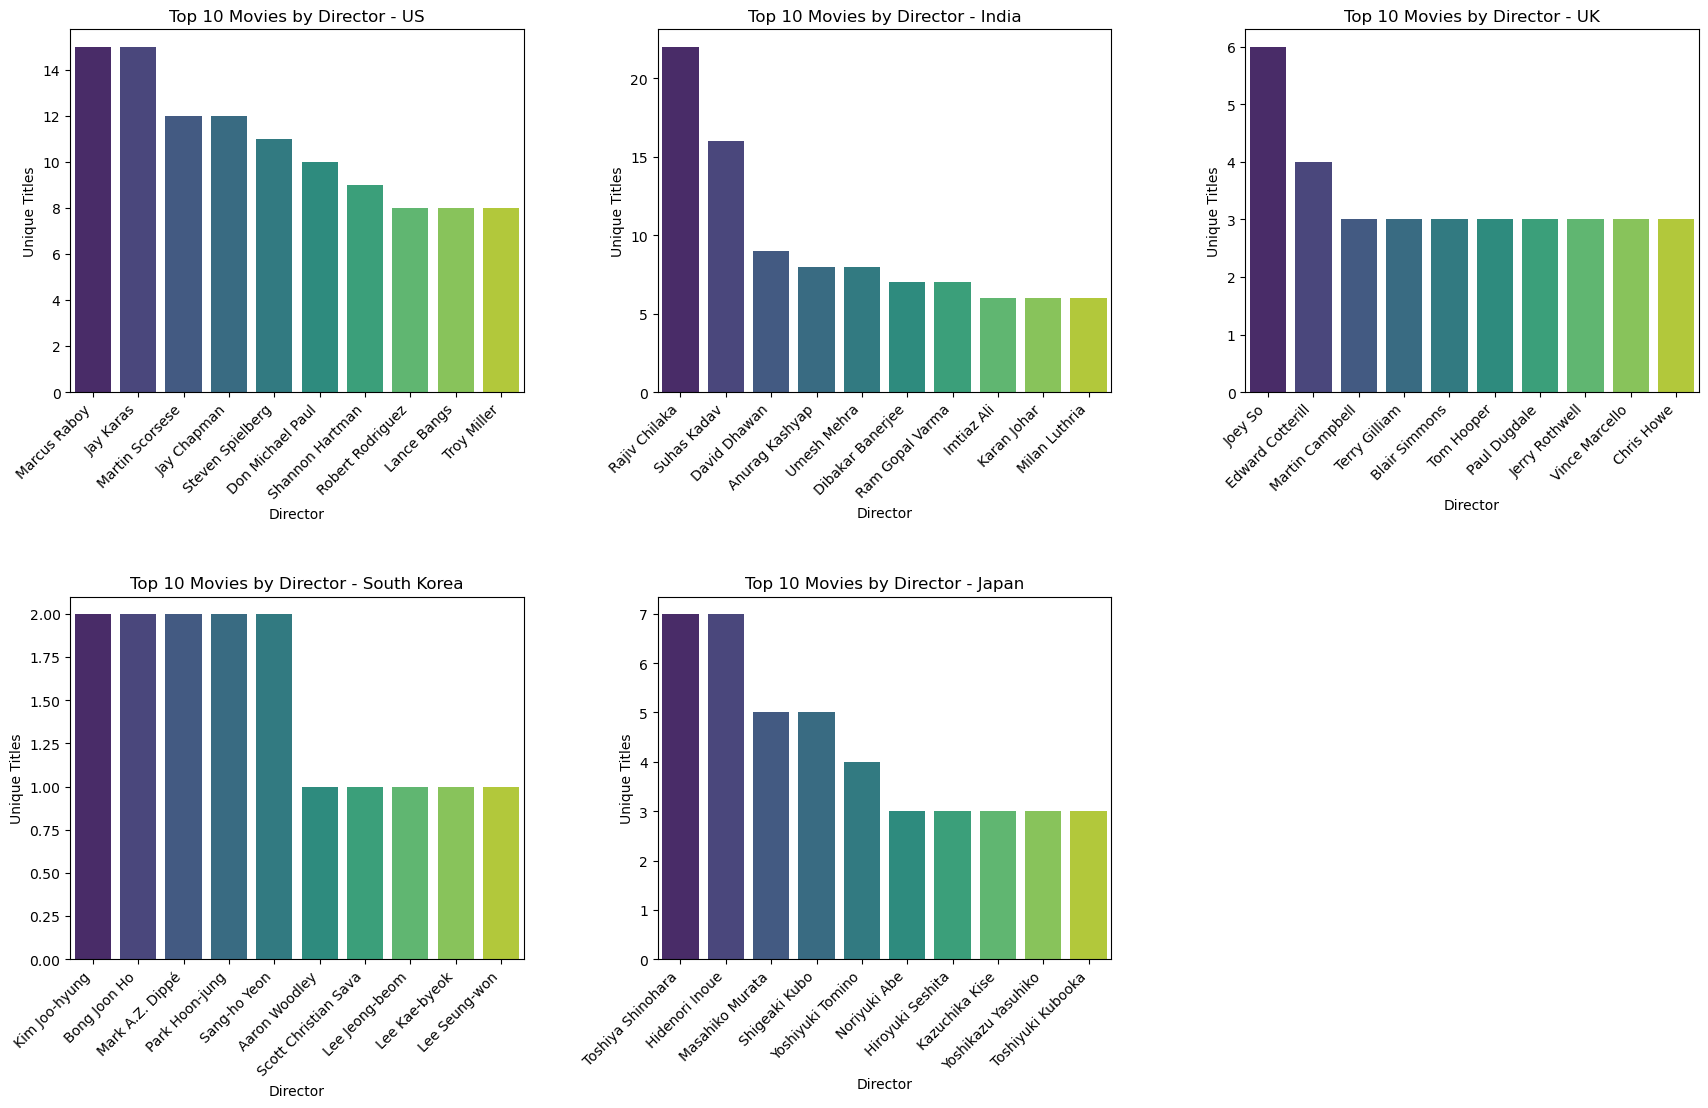

In [675]:
# For movies based on 'Director':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp, column_name='director', media_type='movies',exclude_values=['Unknown Director'])

## 🎬 Movie Director Distribution by Country

### Observations:
- **US**: Directors like Marcus Raboy, Jay Karas, and Martin Scorsese are most prominent in the American film industry, with a mix of comedy and drama.
- **India**: Renowned directors such as Rajiv Chilaka, Suhas Kadav, and David Dhawan lead the Indian film scene, particularly in animation and mainstream cinema.
- **UK**: Directors like Joey So, Martin Campbell, and Terry Gilliam are notable, with a strong representation in drama and fantasy genres.
- **South Korea**: Directors like Kim Joo-hyung and Bong Joon Ho are known for their creative storytelling in both dramas and action films.
- **Japan**: Directors such as Toshiya Shinohara, Hidenori Inoue, and Masahiko Murata dominate Japanese cinema, particularly in animation.

### ➤ Key Insights:
- **US**: A strong mix of directors known for comedy, drama, and action films.
- **India**: A focus on mainstream cinema, with directors leading in both live-action and animated films.
- **UK**: A lot of diversity in direction, particularly in drama and action films.
- **South Korea**: Directors focused on intense dramas and action-packed thrillers.
- **Japan**: Animation and fantasy genres are led by notable directors.

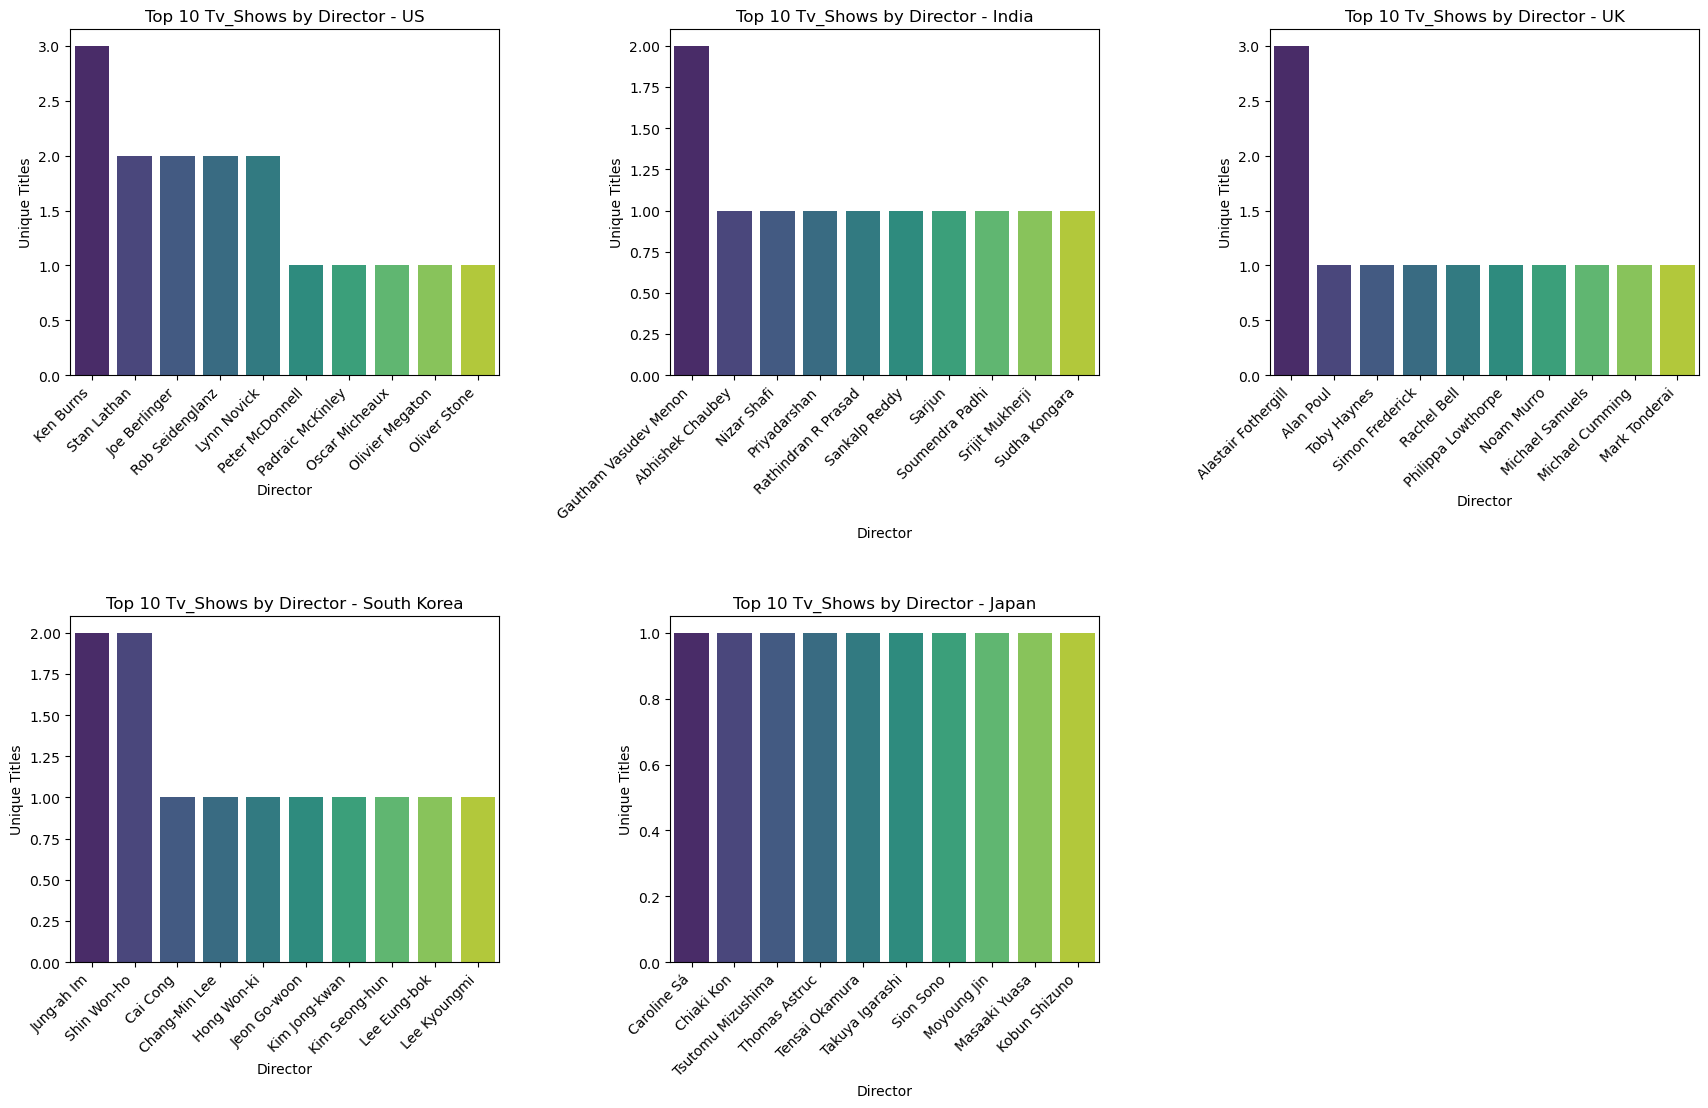

In [677]:
# For tv_shows based on 'Director':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_sk,df_shows_jp, column_name='director', media_type='tv_shows',exclude_values=['Unknown Director'])

## 🎬 TV Show Director Distribution by Country

### Observations:
- **US**: Directors like Ken Burns and Stan Lathan stand out with multiple projects, mainly in documentary and crime genres.
- **India**: Directors such as Gautham Vasudev Menon and Abhishek Chaubey are prominent, especially in crime and drama series.
- **UK**: Alastair Fothergill leads with nature and documentary genres, while other directors focus on drama and crime.
- **South Korea**: Directors like Jung-ah Im and Shin Won-ho are known for drama series with a strong following.
- **Japan**: Directors such as Caroline Sá, Chiaki Kon, and Masaaki Yuasa focus on a mix of animated and live-action TV shows.

### ➤ Key Insights:
- **US**: Primarily documentary and crime genres dominate the TV show direction.
- **India**: A balance of crime, drama, and action series with a variety of director involvement.
- **UK**: Notable for nature documentaries and drama series with strong directorial influence.
- **South Korea**: TV direction leans heavily on dramas, particularly with directors noted for their storytelling skills.
- **Japan**: Animation and diverse genres have directors leading in both TV and animated series.

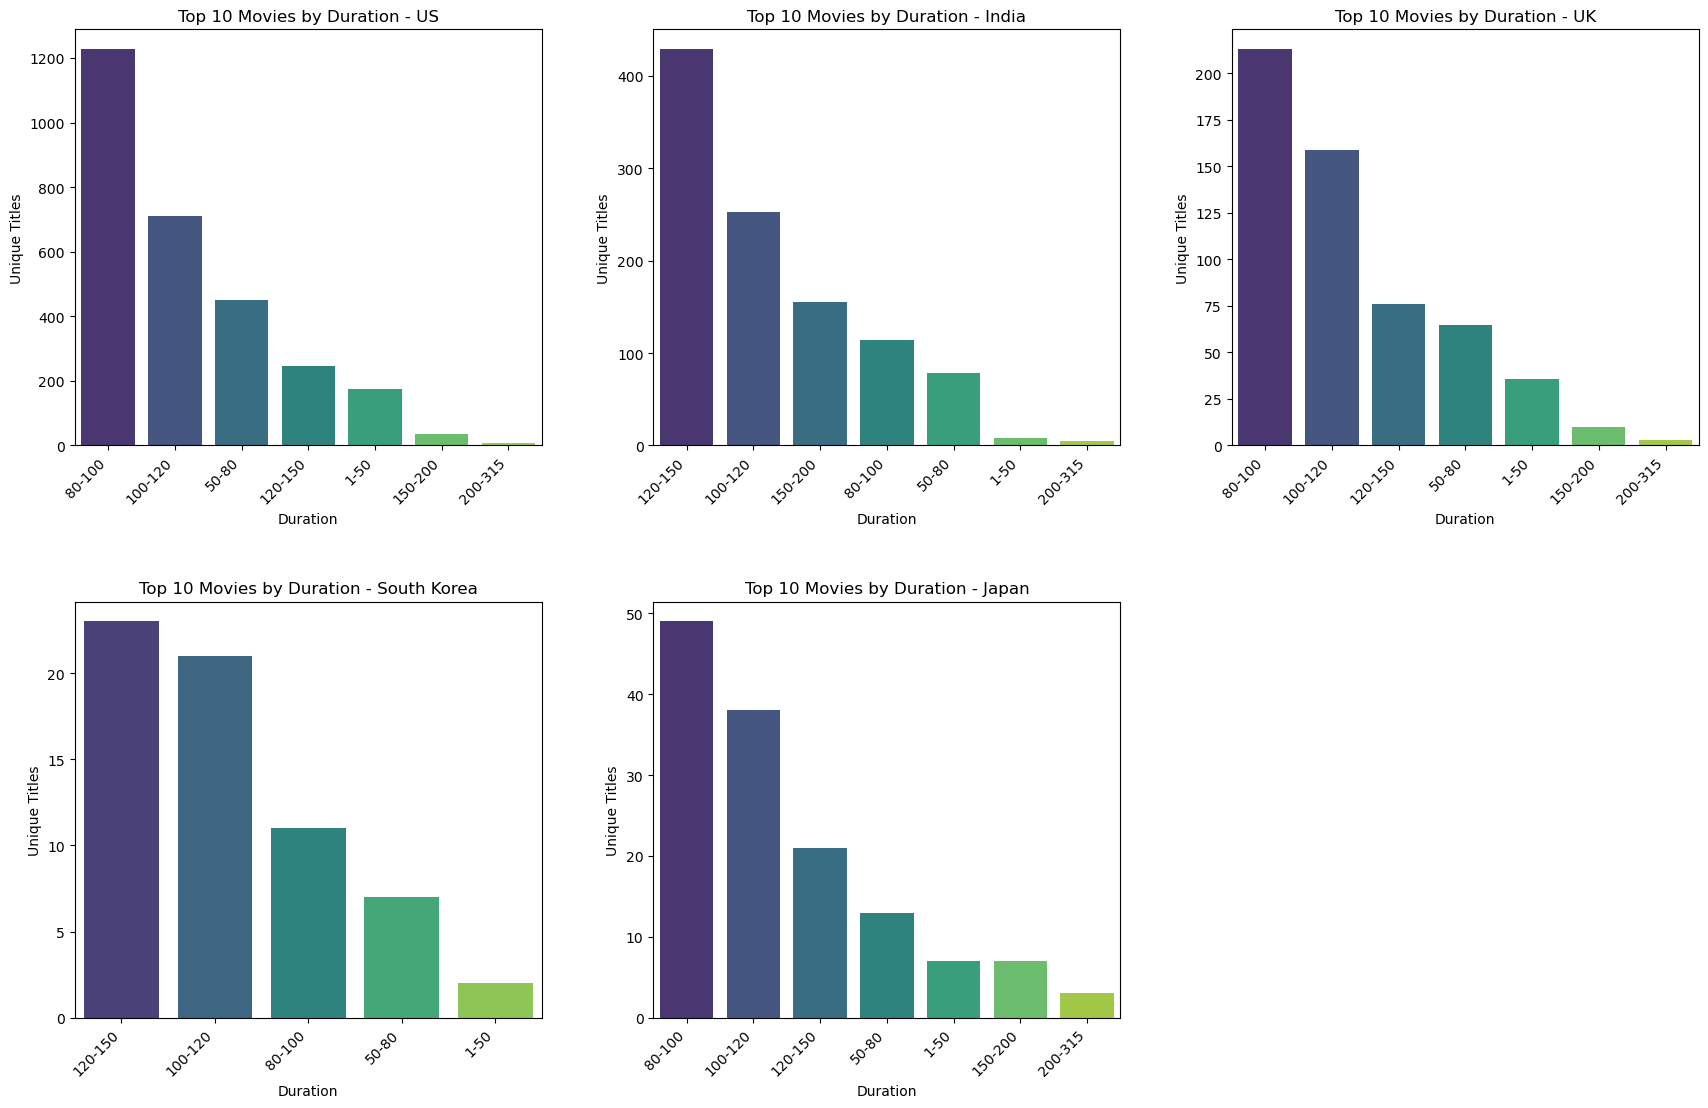

In [679]:
# For movies based on 'duration':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp, column_name='duration', media_type='movies',exclude_values=[0])

## 🎬 Movie Duration Distribution by Country

### Observations:
- **US**: Dominated by movies in the 80–120 minute range. Directors and studios prefer standard runtime formats, with a gradual drop-off for films over 120 minutes.
- **India**: Strong presence of longer-duration films (120–150 minutes), reflecting Bollywood’s tradition of elaborate storytelling.
- **UK**: Follows a similar trend to the US, with a clear concentration in the 80–120 minute range, and fewer long-format movies.
- **South Korea**: Most movies fall within the 100–150 minute range, indicating a preference for compact, story-driven films.
- **Japan**: While 80–120 minutes remains dominant, there's a more balanced spread across categories, including shorter films and a few long-format entries.

### ➤ Key Insights:
- 80–120 mins is the global sweet spot for movie runtimes.
- India stands out for favoring longer films, while Japan showcases greater diversity in duration.
- US and UK maintain a consistent trend with standard-length films, supporting global viewing habits that favor tighter narratives.

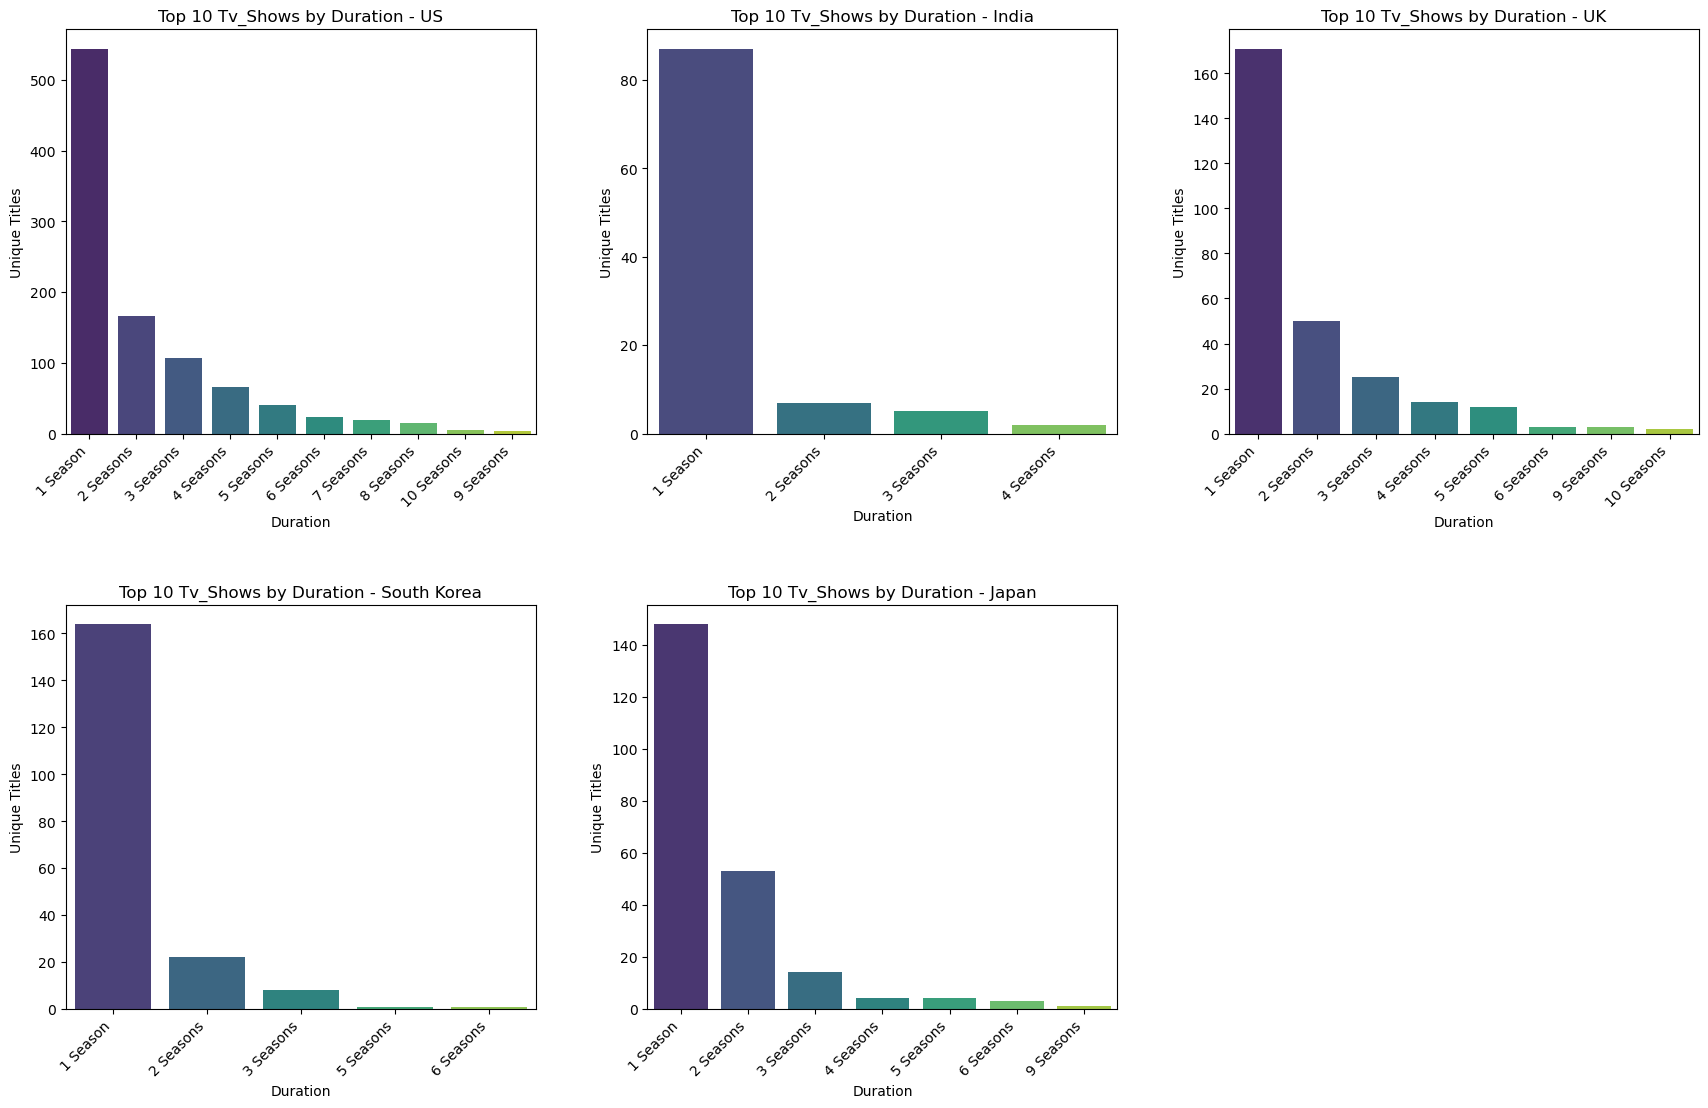

In [681]:
# For tv_shows based on 'Director':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_sk,df_shows_jp, column_name='duration', media_type='tv_shows',exclude_values=[0])

## 🎞️ TV Show Duration by Country

### Observations:
- **US**: Dominated by 1-season shows, with a gradual decline up to 10 seasons, reflecting both limited series and long-running hits.
- **India**: Mostly 1-season content, with very few multi-season series.
- **UK**: Preference for 1–3 seasons, with a few long-running exceptions.
- **South Korea**: Strong focus on single-season dramas, rarely exceeding 2–3 seasons.
- **Japan**: Mostly 1–2 season shows, with occasional longer series.

### ➤ Key Insight:
Globally, 1-season shows are most common, highlighting the popularity of concise, bingeable content. The US and UK offer more long-form series, while India, Korea, and Japan favor shorter formats.

In [683]:
def Analyze_column_trends_by_country(df_us, df_in, df_uk, df_sk, df_jp, column_name, media_type, exclude_values=None):
    def clean_df(df):
        df_clean = df.dropna(subset=[column_name])
        if exclude_values:
            df_clean = df_clean[~df_clean[column_name].isin(exclude_values)]
        return df_clean

    # Clean all five country DataFrames
    df_us = clean_df(df_us)
    df_in = clean_df(df_in)
    df_uk = clean_df(df_uk)
    df_sk = clean_df(df_sk)
    df_jp = clean_df(df_jp)

    # Group by column_name and count unique titles
    us_column_counts = df_us.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)
    in_column_counts = df_in.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)
    uk_column_counts = df_uk.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)
    sk_column_counts = df_sk.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)
    jp_column_counts = df_jp.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)

    # Set up color palettes
    viridis_palette_us = sns.color_palette("viridis", len(us_column_counts))
    viridis_palette_in = sns.color_palette("viridis", len(in_column_counts))
    viridis_palette_uk = sns.color_palette("viridis", len(uk_column_counts))
    viridis_palette_sk = sns.color_palette("viridis", len(sk_column_counts))
    viridis_palette_jp = sns.color_palette("viridis", len(jp_column_counts))

    # # Print counts (optional)
    # print("US:\n", us_column_counts, "\n")
    # print("India:\n", in_column_counts, "\n")
    # print("UK:\n", uk_column_counts, "\n")
    # print("South Korea:\n", sk_column_counts, "\n")
    # print("Japan:\n", jp_column_counts, "\n")


    # Plotting
    plt.figure(figsize=(18, 12))
    
    # US Trend Plot
    plt.subplot(2, 3, 1)
    sns.lineplot(data=us_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - US')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    # India Trend Plot
    plt.subplot(2, 3, 2)
    sns.lineplot(data=in_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - India')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    # UK Trend Plot
    plt.subplot(2, 3, 3)
    sns.lineplot(data=uk_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - UK')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    # South Korea Trend Plot
    plt.subplot(2, 3, 4)
    sns.lineplot(data=sk_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - South Korea')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    # Japan Trend Plot
    plt.subplot(2, 3, 5)
    sns.lineplot(data=jp_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - Japan')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    plt.tight_layout(pad=4.0)
    plt.show()

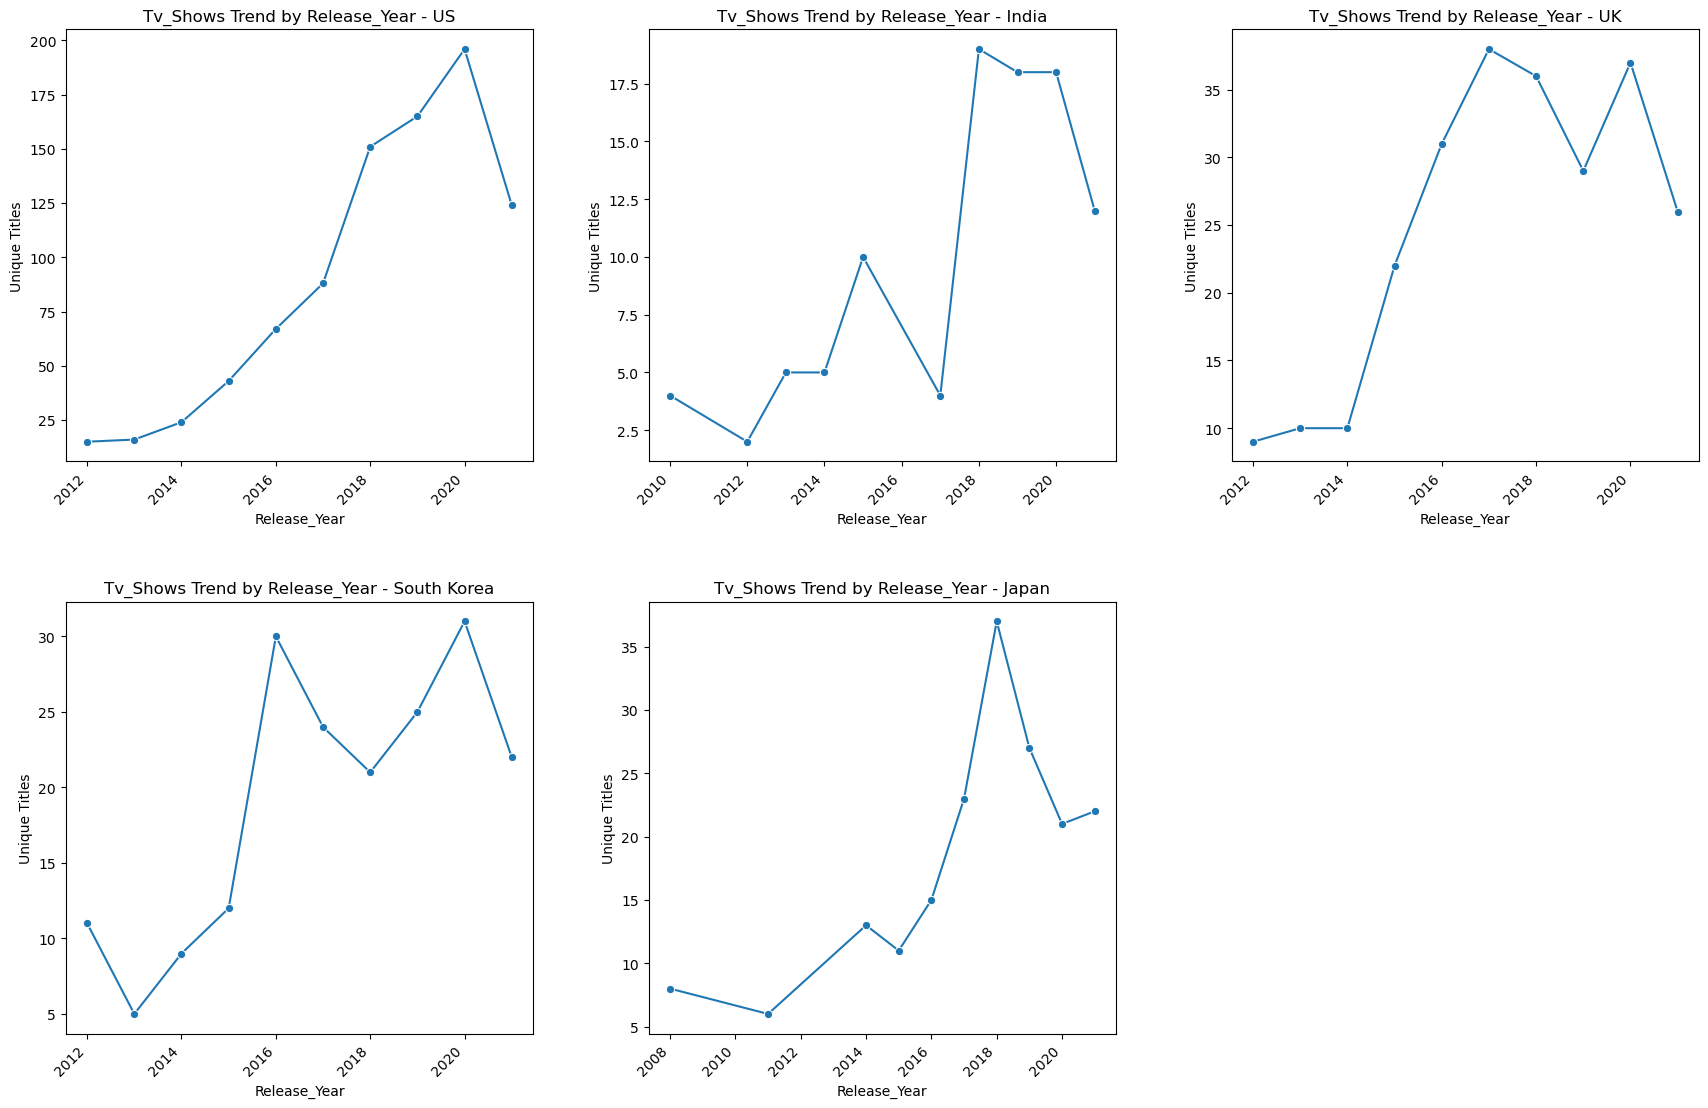

In [684]:
Analyze_column_trends_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_sk,df_shows_jp, column_name='release_year', media_type='tv_shows')

## 🎬 TV Show Release Year Trends by Country

### Observations:
- **US**: Major increase in titles since 2018, peaking in 2020 with 196 titles.
- **India**: 2018 and 2019 had the highest number of releases, each with 18 titles. After that, there was a drop, with 2021 seeing a notable decline (12 titles).
- **UK**: Peak in 2017, followed by a decline. 2020 and 2018 saw strong releases.
- **South Korea**: A spike in 2020, but consistent releases in 2016 and 2019.
- **Japan**: 2018 leads with 37 titles, followed by 2019. Releases were consistent across years.

### ➤ Key Insights:
- **US**: Dominant peak in 2020.
- **India**: Slump after 2018.
- **UK and South Korea**: Stable years with small peaks.
- **Japan**: Steady releases with a strong 2018.

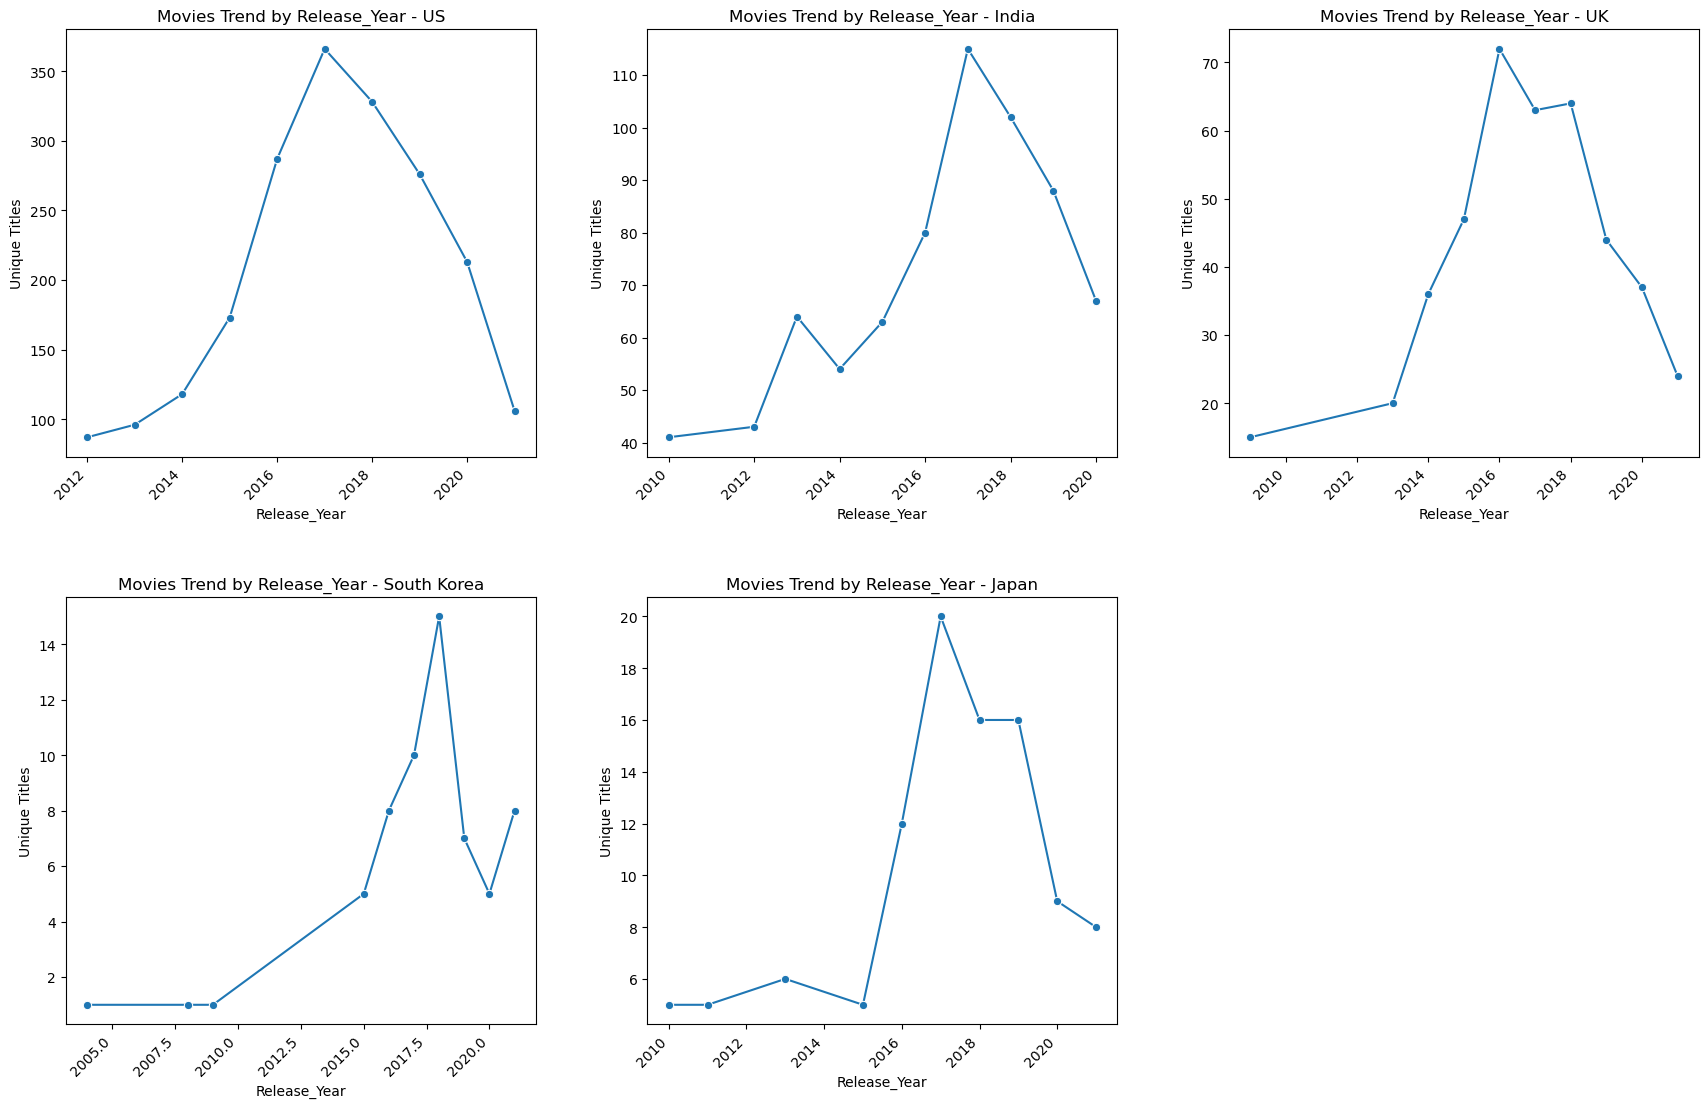

In [686]:
# For movies based on 'release_year':
Analyze_column_trends_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp, column_name='release_year', media_type='movies')

## 🎬 Movies Trends by Country

### Observations:
- **US**: Peak in 2017 (366) and 2018 (328), but a sharp decline in 2020 and 2021.
- **India**: Highest in 2017 (115) and 2018 (102), with a decline in later years.
- **UK**: 2016 (72) had the most releases, followed by a drop to 24 in 2021.
- **South Korea**: 2018 (15) had the most, followed by a decline in later years.
- **Japan**: 2017 tops with 20, then declines in 2021 (8).

### ➤ Key Insight:
- Most countries saw a decline in releases after 2017-2019, with significant drops in 2020-2021.

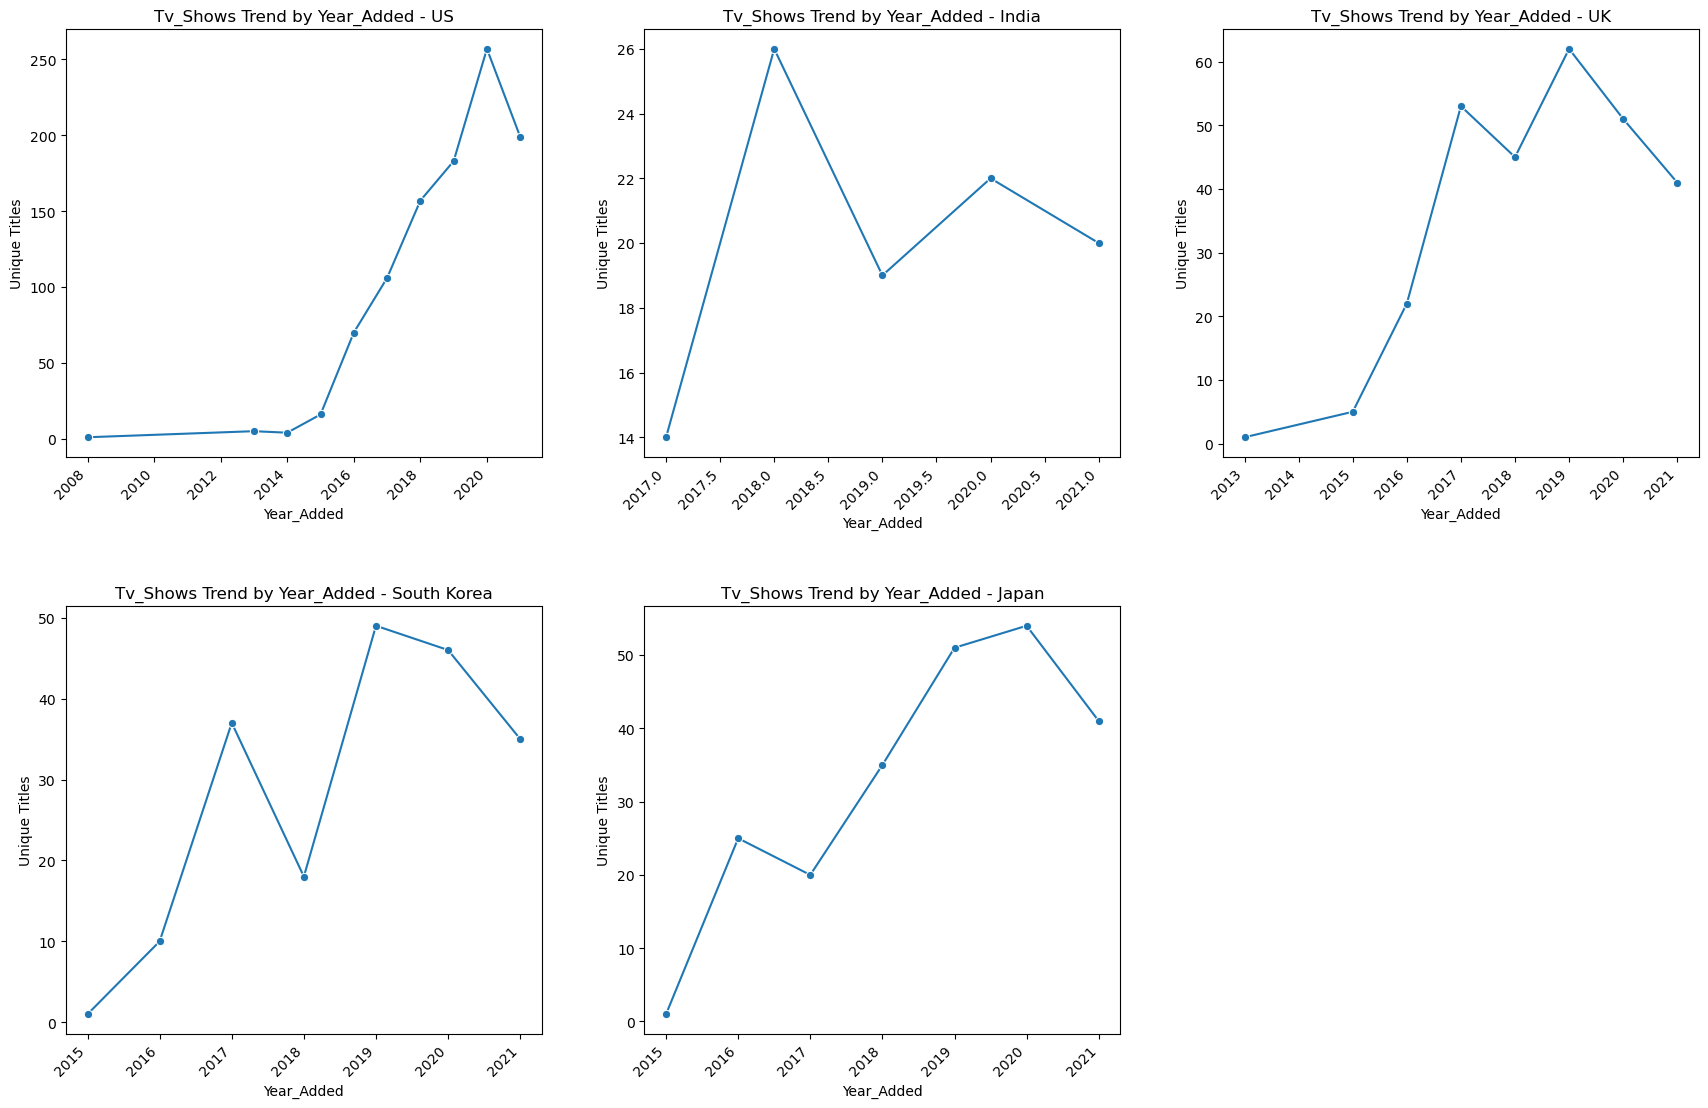

In [688]:
# For tv_shows based on 'year_added':
Analyze_column_trends_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_sk,df_shows_jp, column_name='year_added', media_type='tv_shows')

## 🎬 TV Shows Trends by Year Added

### Observations:
- **US**: Peak in 2020 (257) and 2021 (199), fewer additions in earlier years.
- **India**: Most shows added in 2018 (26), followed by 2020 (22) and 2021 (20).
- **UK**: Highest in 2019 (62), with strong additions in 2020 (51) and 2021 (41).
- **South Korea**: Peak in 2019 (49) and 2020 (46), slight decrease in 2021 (35).
- **Japan**: Top additions in 2020 (54) and 2019 (51), with a modest decline in 2021 (41).

### ➤ Key Insight:
Most countries experienced a surge in TV show additions during 2020–2021, aligning with increased streaming demand during the pandemic, while earlier years had fewer additions.

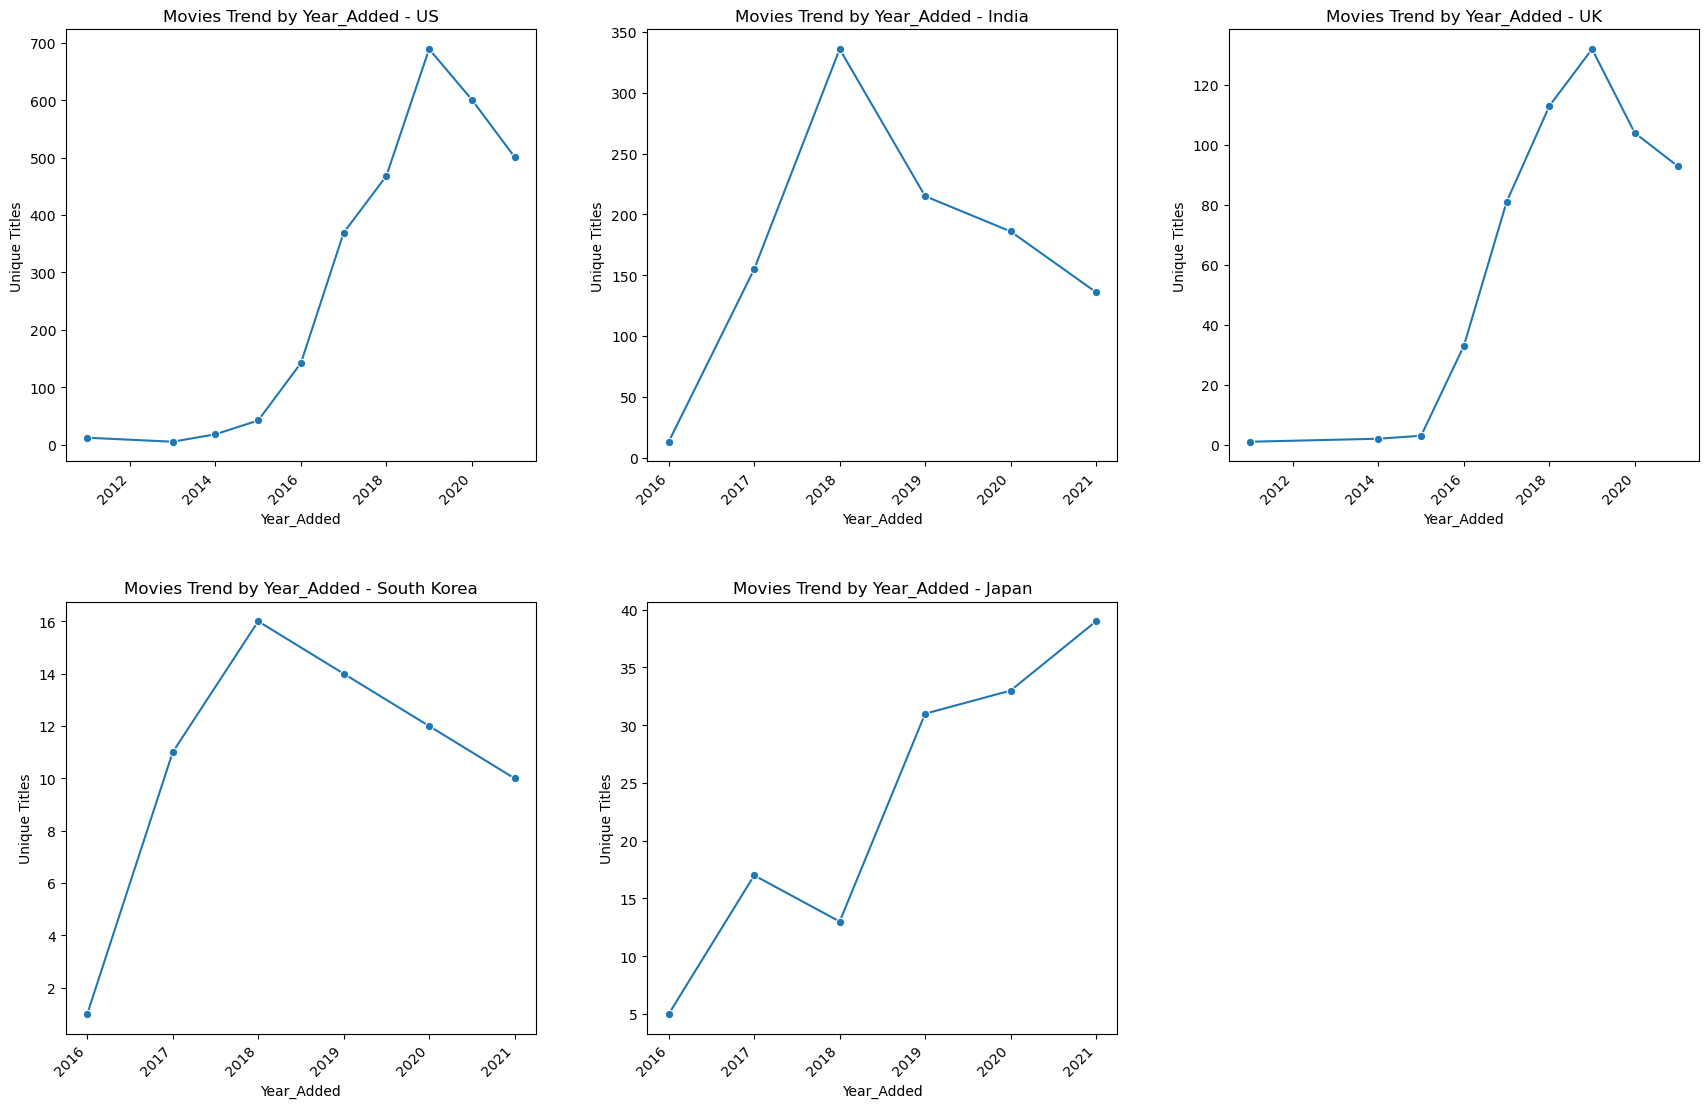

In [690]:
# For movies based on 'year_added':
Analyze_column_trends_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp, column_name='year_added', media_type='movies')

## 🎬 Movies Trends by Year Added

### Observations:
- **US**: Peak in 2019 (689), followed by 2020 (601) and a drop in 2021 (501).
- **India**: Highest in 2018 (336), then a declining trend through 2019 (215), 2020 (186), and 2021 (136).
- **UK**: Most movies added in 2019 (132), then 2018 (113) and 2020 (104).
- **South Korea**: Peak in 2018 (16), with a steady decrease—2020 (12), 2021 (10).
- **Japan**: Uniquely, highest in 2021 (39), followed by 2020 (33) and 2019 (31).

### ➤ Key Insight:
2019 marked the peak year for movie additions across most countries, especially in the US and UK. However, Japan saw its peak later in 2021, indicating a different content acquisition trend. Overall, 2021 reflects a general decline in movie additions for most regions.

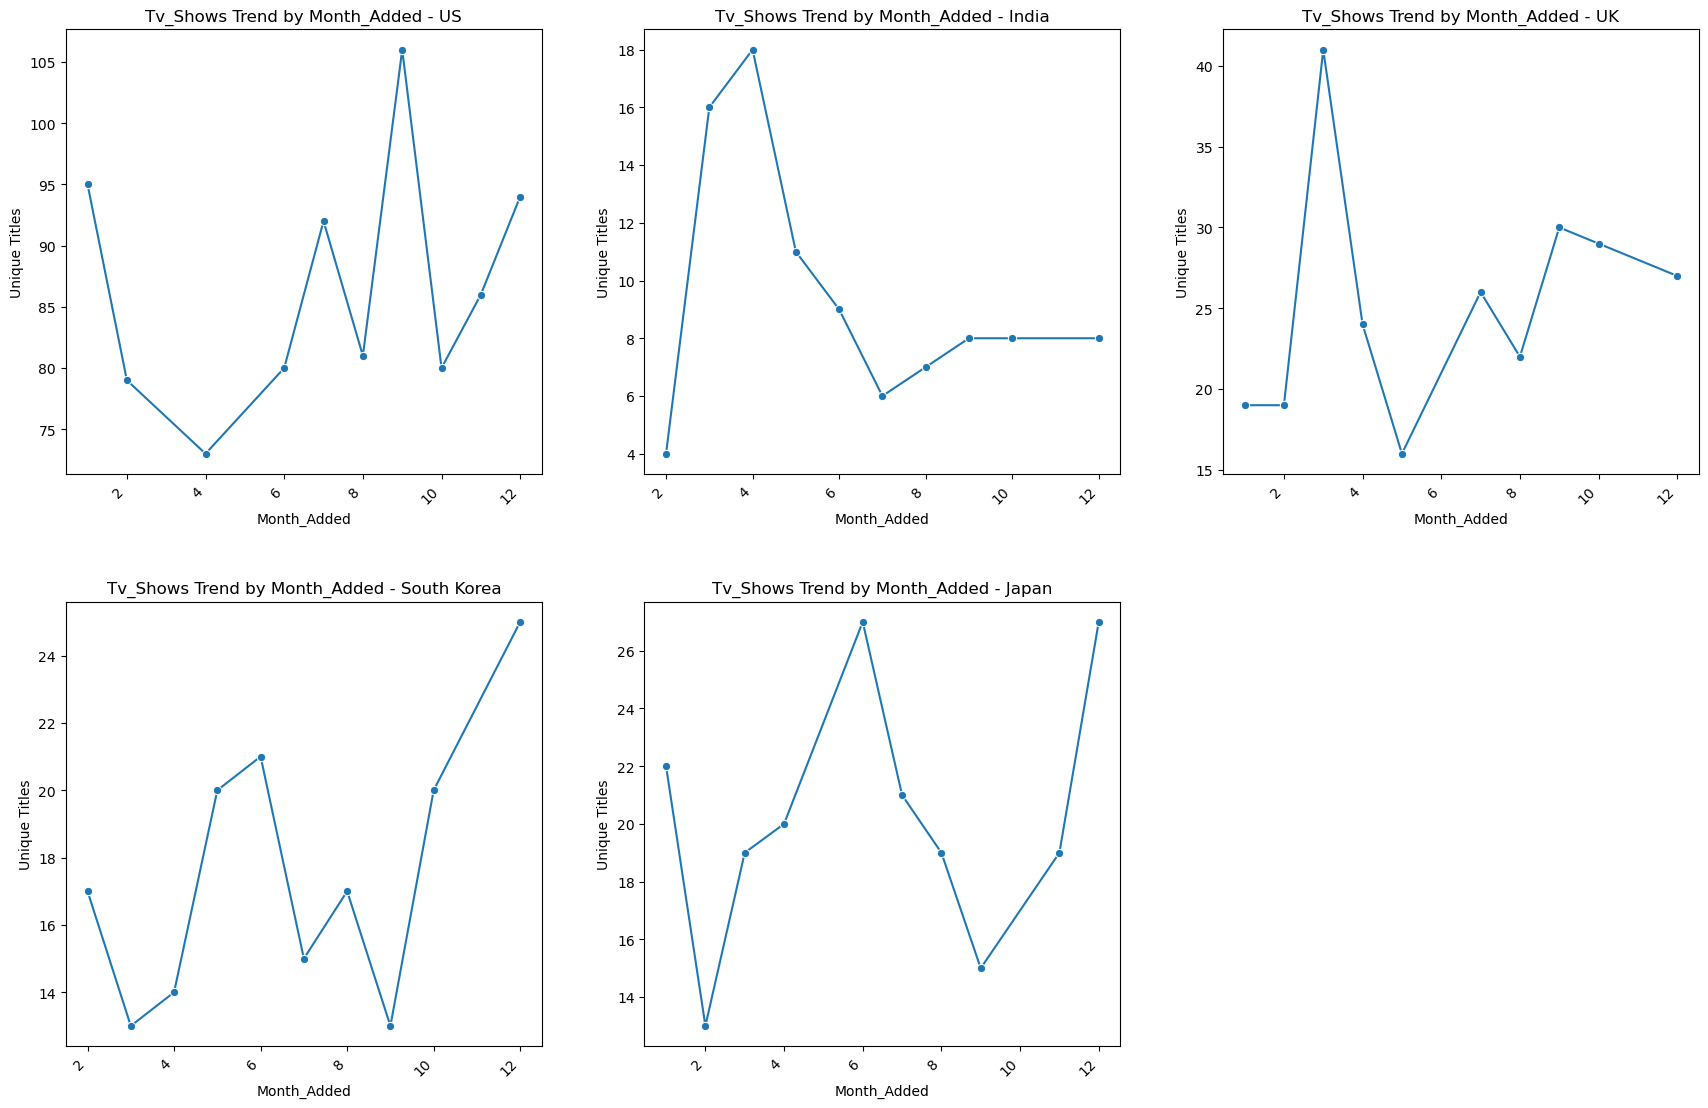

In [692]:

# For tv_shows based on 'month_added':
Analyze_column_trends_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_sk,df_shows_jp, column_name='month_added', media_type='tv_shows')

## 🎬 TV Shows Trends by Month Added

### Observations:
- **US**: Peak in **September (106)**, followed by **January (95)** and **December (94)** — suggesting strong additions during end/start of the year.
- **India**: Peak in **April (18)**, then **March (16)** and **May (11)** — indicating a spring release focus.
- **UK**: Most shows added in **March (41)**, then **September (30)** and **October (29)** — showing activity in early and late parts of the year.
- **South Korea**: Highest in **December (25)**, followed by **June (21)** and **May (20)** — year-end and mid-year release preferences.
- **Japan**: Tied peaks in **June (27)** and **December (27)**, followed by **January (22)** and **July (21)** — indicating consistency in content addition throughout the year.

### ➤ Key Insight:
- The **US** aligns TV show additions with **late summer and holiday seasons**.
- **India** leans towards **spring months**.
- **South Korea and Japan** show **year-end peaks**, with Japan showing a **biannual rhythm** in June and December.

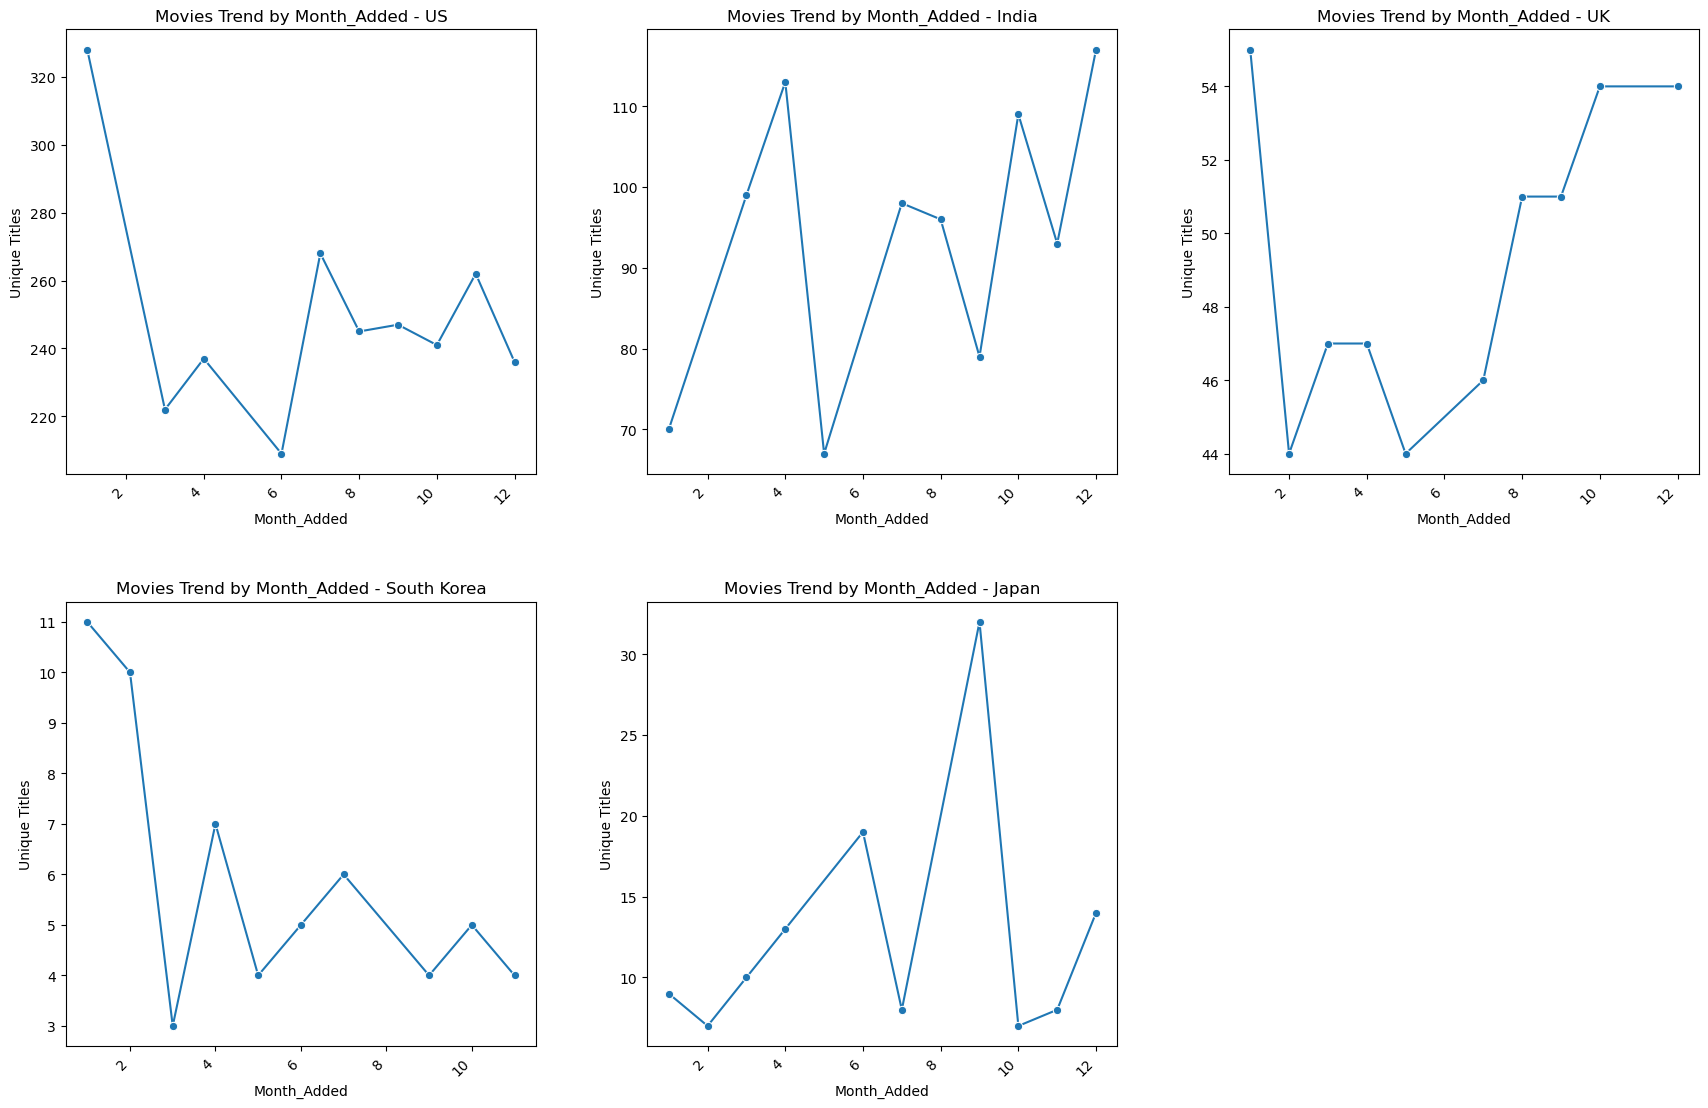

In [694]:
# For movies based on 'month_added':
Analyze_column_trends_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp, column_name='month_added', media_type='movies')

## 🎬 Movies Trends by Month Added

### Observations:
- **US**: Major spike in **January (328)**, followed by **July (268)** and **November (262)** — suggesting content pushes after holidays and in summer/fall.
- **India**: Highest in **December (117)**, then **April (113)** and **October (109)** — indicating strong end-of-year and festival season updates.
- **UK**: Peaks in **January (55)**, **October (54)**, and **December (54)** — consistent with holiday and year-end programming.
- **South Korea**: Most in **January (11)**, followed by **February (10)** and **April (7)** — suggesting start-of-year content refresh.
- **Japan**: Peak in **September (32)**, then **June (19)** and **December (14)** — a mix of mid- and end-of-year additions.

### ➤ Key Insight:
- **January** is a strong month for movie additions globally, particularly in the **US**, **UK**, and **South Korea**.
- **India** aligns with **December**, possibly due to festive seasons.
- **Japan** shows a unique peak in **September**, with a balanced mid-year and end-year distribution.

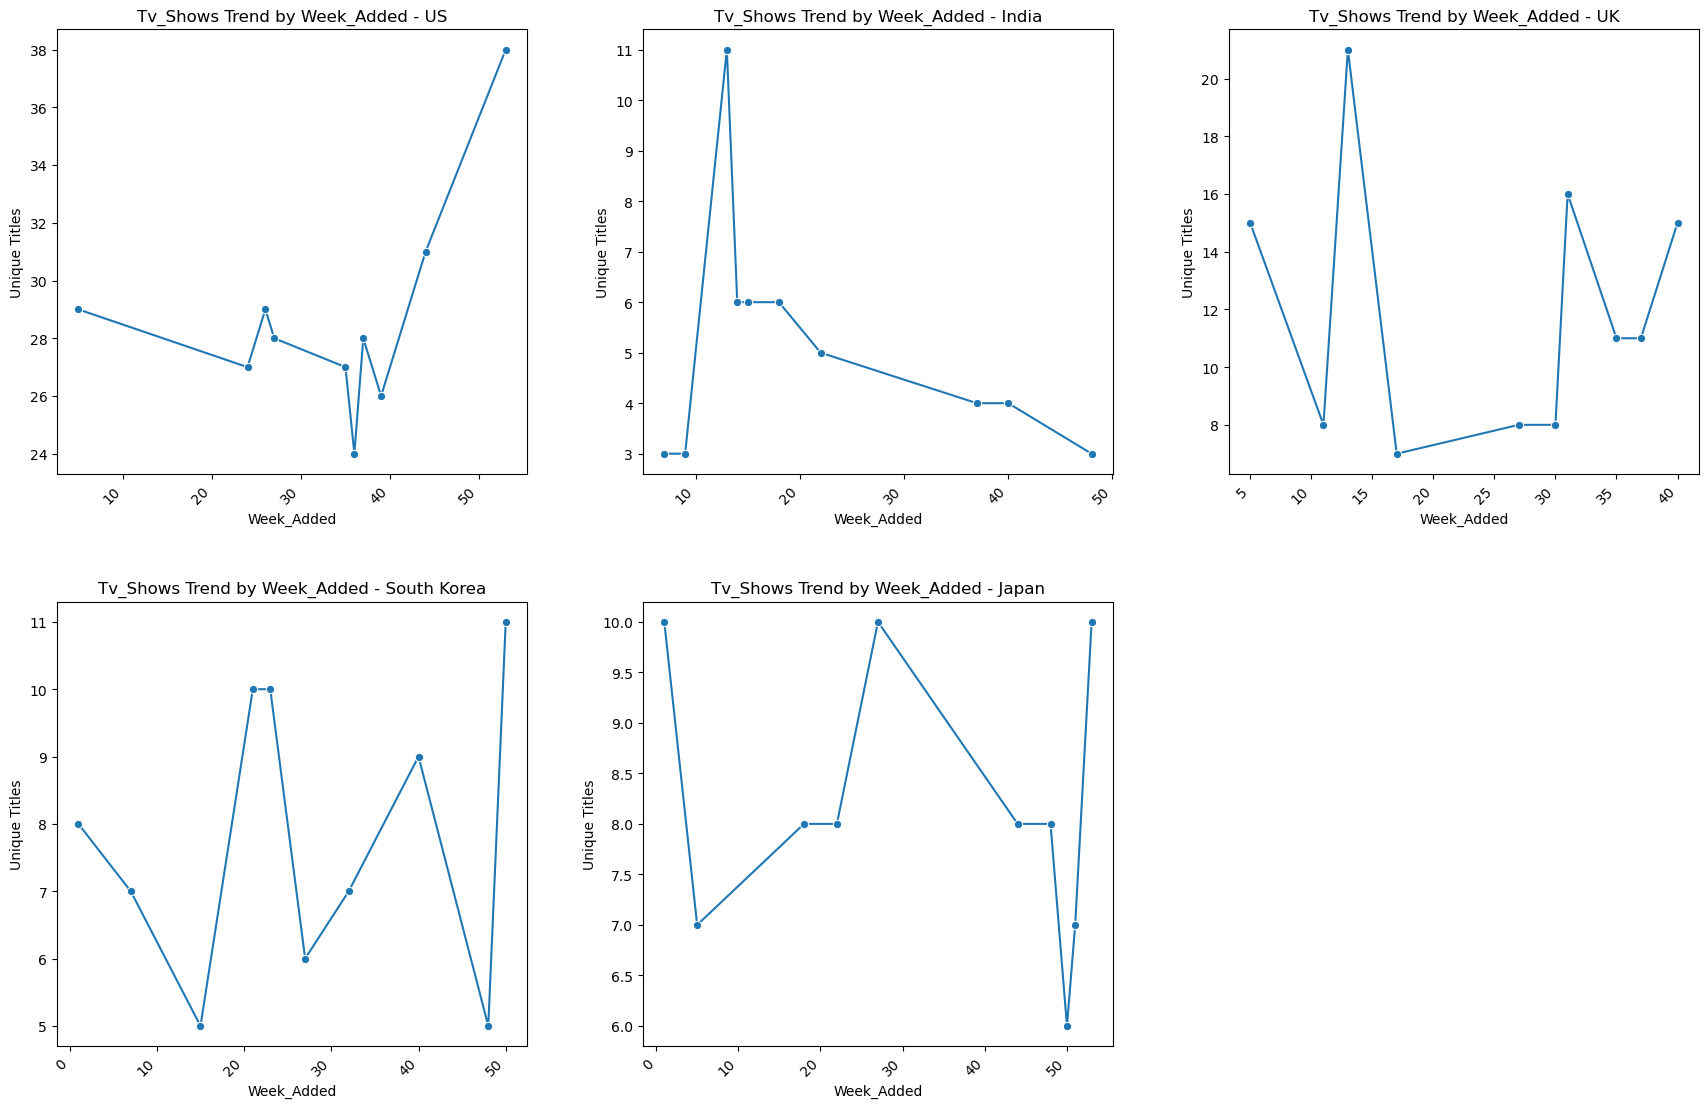

In [696]:


# For tv_shows based on 'week_added':
Analyze_column_trends_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_sk,df_shows_jp, column_name='week_added', media_type='tv_shows')

## 🎬 TV Shows Trends by Week Added

### Observations:
- **US**: The most shows were added in **weeks 53** (38), **44** (36), and **26** (33) — showing a wide distribution of shows across the year with notable peaks in late December and early fall.
- **India**: Peak in **week 13** (11 shows), with other notable weeks like **14**, **15**, and **18** contributing **6 shows** each — indicating a trend of content additions around mid-year.
- **UK**: Notable weeks include **week 13** (21 shows), **week 31** (16 shows), and **week 5** (15 shows) — showing concentrated releases around specific weeks.
- **South Korea**: Peaks in **week 50** (11 shows), with weeks **21** and **23** also adding **10 shows** each — pointing to a trend of high releases in late fall.
- **Japan**: Peak in **week 1** (10 shows), followed by **week 27** and **week 53** with **10 shows** each — with consistent content drops at the beginning and end of the year.

### ➤ Key Insight:
- **US** shows a wide distribution of shows over the weeks, with notable spikes in **weeks 53** and **44**.
- **India** shows a peak in **week 13**, reflecting a trend in content additions around mid-year.
- **UK**, **South Korea**, and **Japan** show smaller but consistent trends, with peaks in **week 13** for the UK and **week 50** for South Korea.

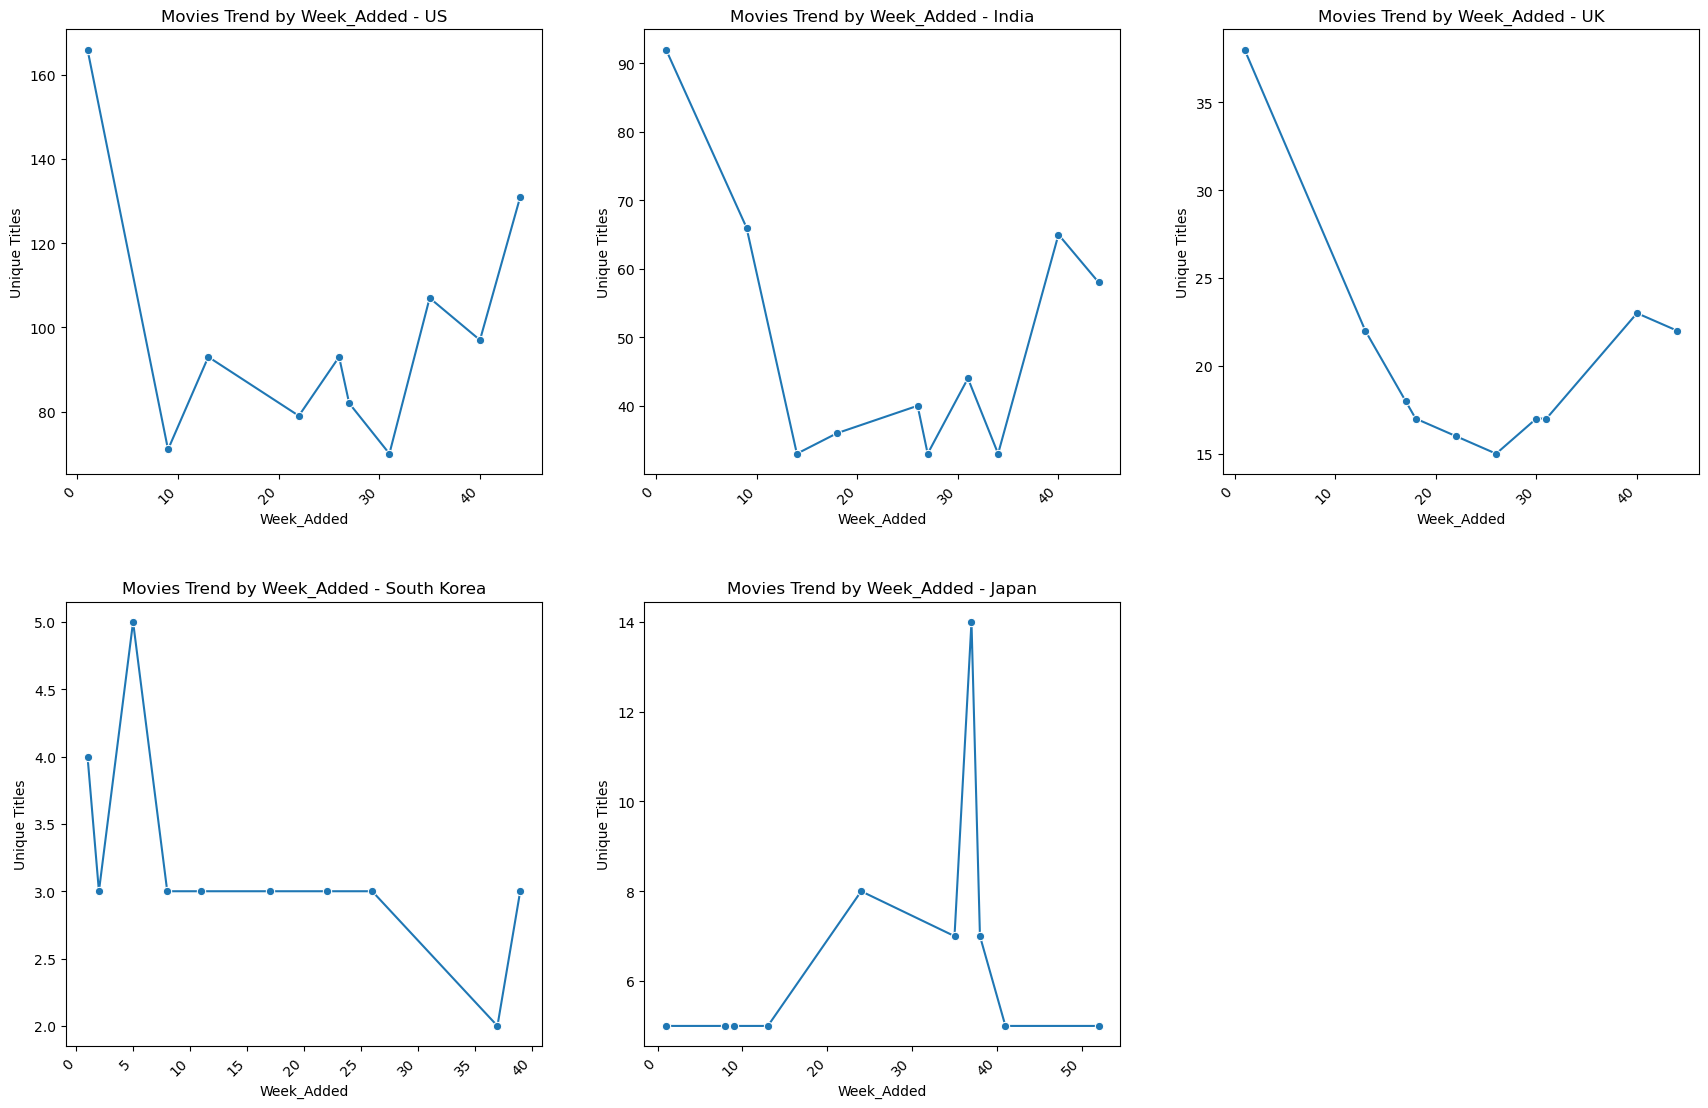

In [698]:
# For movies based on 'week_added':
Analyze_column_trends_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp, column_name='week_added', media_type='movies')

## 🎬 Movies Trends by Week Added

### Observations:
- **US**: Peak in **week 1** (166), followed by **week 44** (131) and **week 35** (107) — showing a surge of movie additions early in the year and during key fall periods.
- **India**: Highest in **week 1** (92), with other peaks in **week 9** (66) and **week 40** (65) — indicating strong releases at the start of the year and around festival periods.
- **UK**: Mostly in **week 1** (38), with notable weeks **40** (23) and **44** (22) — consistent with holiday and year-end programming.
- **South Korea**: Peak in **week 5** (5), with steady additions in **week 1** and **week 11** — showing more gradual content additions throughout the year.
- **Japan**: Highest in **week 37** (14), followed by **week 24** (8) — showing some distinct peaks later in the year.

### ➤ Key Insight:
- **US** and **India** show significant movie additions in **week 1**, while **UK**, **South Korea**, and **Japan** show more gradual content drops.

In [797]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Netflix_Datacleaning.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/EDA on Netflix-checkpoint.ipynb
	.ipynb_checkpoints/Netflix_Datacleaning-checkpoint.ipynb
	.ipynb_checkpoints/Netflix_cleaned_data-checkpoint.csv
	.ipynb_checkpoints/README-checkpoint.md
	EDA on Netflix.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


fatal: pathspec 'EDA\' did not match any files
